# Analysis of GW231123

**Author:** Khushi Verma  
**Course:** Observational Gravitational Wave Astronomy, MSc Data-Intensive Astrophysics, Cardiff University

This notebook presents an end-to-end analysis of **GW231123_135430**, a short-duration high-mass binary black hole merger reported by the LIGO–Virgo–KAGRA Collaboration (Abac et al. 2025). Using open strain data from the LIGO Hanford (H1) and Livingston (L1) detectors, the analysis covers:

1. **Data and noise model** — PSD estimation (Welch + Tukey window), whitening, and band-pass filtering.
2. **Signal modelling** — CBC waveform generation with `pycbc.waveform` and a phenomenological sine-Gaussian burst model.
3. **Detection** — Matched-filter SNR time series for both models, with a False Alarm Rate (FAR) bound estimated via time slides over an extended off-source background.
4. **Parameter estimation** — Reduced coherent analysis with both models. Posteriors are first localised by optimisation, then sampled with the `emcee` ensemble MCMC sampler, and visualised with corner plots.

All data is fetched from the [Gravitational Wave Open Science Center (GWOSC)](https://gwosc.org).

## Introduction

Research in gravitational waves (GW) took a huge boom in signal analysis and pipeline testing when the LIGO detectors made the first direct GW detection, GW150914, from a black hole binary on 14 September 2015 (Abbott et al. 2016). Since then, many such signals have been detected from binary black hole (BBH) mergers, along with binary neutron star events such as GW170817 (Abbott et al. 2017). Due to this, extensive research has been done into the processing, analysis, and inference of these signals to find the source parameters using the strain data. There are multiple pipelines, and different numerical relativity and waveform models for detection significance and parameter inference. There are well-modelled waveform templates that exist for binary black hole systems of lower (stellar) masses, called compact binary coalescences (CBCs), which makes it easier to infer their parameters with better confidence through techniques such as matched filtering of the strain data against the waveform template. However, some events are more difficult to analyse, such as massive black hole binary systems, because their signal is very short, with only a few cycles in the sensitive band. These signals appear more like a burst and are very sensitive to the presence of glitches in the detector. This also makes parameter estimation more challenging, as it becomes more sensitive to waveform model choices.

GW231123 is one such event. While most confidently detected signals so far have come from stellar-mass binary systems, events at much higher total mass are far more difficult to interpret. The previous most massive event of this kind was GW190521, which was the first strong candidate for the formation of an intermediate-mass black hole (Abbott et al. 2020; Abac et al. 2025). GW231123, however, has a total mass in the range 190–265 $M_\odot$ and therefore lies in an even more extreme part of the parameter space (Abac et al. 2025). It was detected by the LIGO Livingston and Hanford observatories on 23 November 2023 and was a very short, low-frequency signal from a high-mass black hole binary system. This signal was of particular interest due to its short duration ($\sim 0.1\,\mathrm{s}$) and because it had only about 5 cycles in the sensitive range of the detector (Abac et al. 2025). Because of this short duration, the event is harder to interpret than ordinary stellar-mass BBH signals, both because it looks more burst-like in the detector data and because the inferred source properties are more sensitive to waveform-systematic effects (Abac et al. 2025). This also makes it useful to compare a physically motivated CBC model with a phenomenological burst model, since for a signal this short it is important to test whether the event is better described by detailed binary coalescence structure or by a simpler generic transient burst morphology. In this assignment, I analyse GW231123 using both kinds of models and carry out a simplified version of detection and parameter inference to study how well each model describes the signal. The parameter-estimation setup and FAR/IFAR estimate used here are reduced and simplified versions of the full analysis, and are meant to capture the main physical ideas rather than reproduce the complete LVK pipeline results.

The rest of this notebook is organised as follows. I begin by downloading open-strain data around GW231123 from the Hanford and Livingston detectors and inspecting the raw time-series behaviour of the event. I then estimate the detector power spectral density (PSD), which is needed to understand the data's noise properties and to perform whitening and matched-filter calculations. After whitening and band-pass filtering the data, I compare two possible signal descriptions for GW231123: a literature-motivated compact binary coalescence (CBC) waveform and a phenomenological sine-Gaussian burst model. These are first compared directly in the time domain to assess their morphology by eye, and then used as templates in a simplified coincident-detection analysis. For the detection step, I compute the matched-filter signal-to-noise ratio (SNR) time series for both models in each detector separately, compare their behaviour around the event time, and then estimate a bound on the false alarm rate using time-slide background coincidences. Finally, I perform a reduced-coherence parameter-estimation exercise for both the CBC and burst models, varying only a small set of timing, amplitude, and phase parameters. This last part explores, in a simpler setting, how model choice affects the interpretation of a short, high-mass signal like GW231123.

In [ ]:
# installing the necessary libraries
!pip install -q gwosc gwpy pycbc lalsuite

In [ ]:
# importing
import numpy as np
import matplotlib.pyplot as plt

from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries as gwpytimeseries


/usr/local/lib/python3.12/dist-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In this section, I start by downloading the open strain data for GW231123 from the two LIGO detectors, Hanford (H1) and Livingston (L1), and examine the data around the event time. I then estimate the power spectral density (PSD) of the detector noise, which is needed both to understand the frequency-dependent noise behaviour of the detectors and to whiten the strain data properly. Finally, I whiten and band-pass filter the data in order to suppress the dominant noise contributions and better highlight the signal morphology near the event time.

### Part A

I first download the open strain data for GW231123 from the two LIGO detectors that observed the signal, Hanford and Livingston(Abac et al. 2025). The strain data are publicly available through the Gravitational Wave Open Science Center (GWOSC), which provides open detector data for event-based analysis. For the main data segment, I fetch a time window of $\pm 32\,\mathrm{s}$ around the event time. This is much longer than the signal itself, but it gives enough surrounding data for later preprocessing steps such as PSD estimation, whitening, and filtering. For the raw strain plot, I use a smaller $\pm 4\,\mathrm{s}$ interval so that the data around the event can be viewed more clearly.

In [ ]:
event_name='GW231123_135430'
t0=event_gps(event_name)
ifos = ['H1', 'L1']

pad = 32

# 32s segment raw strain data for later preprocessing
data = {ifo: gwpytimeseries.fetch_open_data(ifo, t0-pad, t0+pad, cache=True) for ifo in ifos}

# cropped data for plotting the raw strain
plot_data={ifo:data[ifo].crop(t0-4, t0+4) for ifo in ifos}

print(f'Event(GW231123) GPS Time : {t0}')

# print the relevant data information
for ifo in ifos:
  print(f'{ifo}: duration = {data[ifo].duration.value:.1f} s, sample rate = {data[ifo].sample_rate.value:.1f} Hz')


Event(GW231123) GPS Time : 1384782888.7
H1: duration = 64.0 s, sample rate = 4096.0 Hz
L1: duration = 64.0 s, sample rate = 4096.0 Hz


In [ ]:
# oficial LIGO colors
ifo_colors={
    'H1': "gwpy:ligo-hanford",
    'L1': "gwpy:ligo-livingston"
}

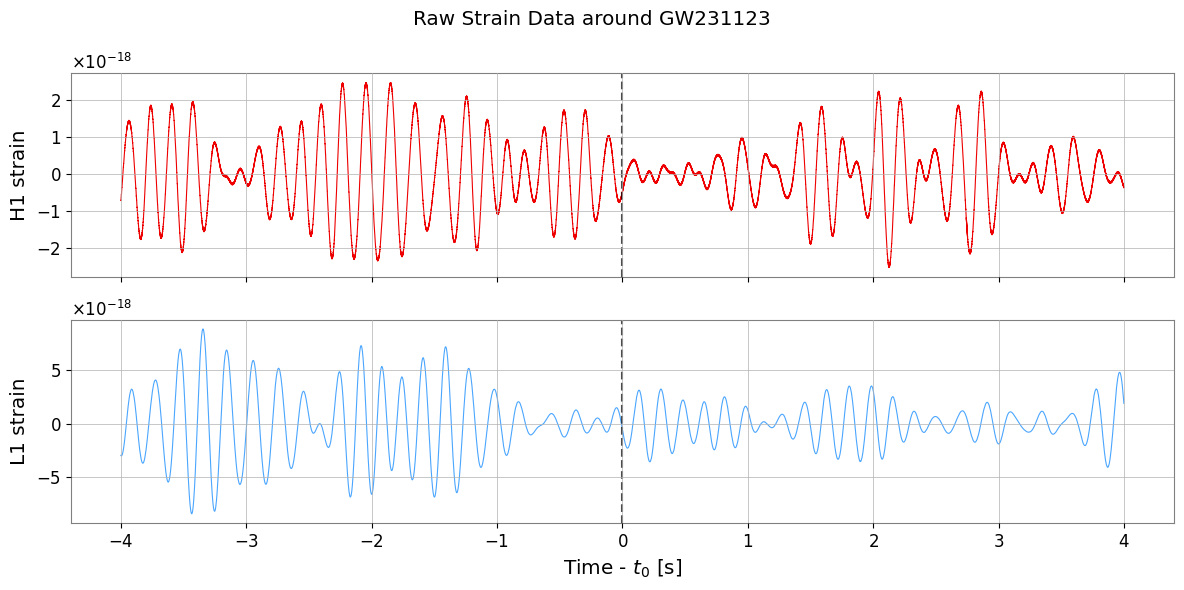

In [ ]:
# plottng the raw strain data from H1 and L1 around the event time
fig, axes = plt.subplots(2,1,figsize=(12,6), sharex=True)

for ax, ifo in zip(axes,ifos):
  ax.plot(plot_data[ifo].times.value -t0, plot_data[ifo].value, color=ifo_colors[ifo], lw=0.8)
  ax.axvline(0, color='k', linestyle='--', alpha=0.7)
  ax.set_ylabel(f'{ifo} strain')


axes[-1].set_xlabel(r'Time - $t_0$ [s]')
fig.suptitle('Raw Strain Data around GW231123')
plt.tight_layout()
plt.show()

The plot above shows the raw strain data from H1 and L1 around the event time. The gravitational-wave signal is not immediately obvious by eye in either detector, which is expected at this stage. In the raw strain, the detector noise is much larger than the signal, especially for a short-duration event like GW231123.

### Part B

Next, I calculate the power spectral density (PSD) of the data to model the detector noise. The PSD tells us how the noise power is distributed as a function of frequency, and it is a necessary step in GW data analysis because the detector noise depends strongly on frequency. To calculate the PSD, I use a longer data segment of $\pm 128\,\mathrm{s}$ around the event, so that the estimate is more stable than it would be if only the short plotting window were used.

I estimate the PSD using Welch averaging with a Hann window. The strain data are split into $4\,\mathrm{s}$ segments with $2\,\mathrm{s}$ overlap, and the individual segment PSD estimates are then averaged to obtain a smoother estimate of the detector noise. The overlap improves the stability of the estimate, while the window reduces spectral leakage from the segment boundaries.

In [ ]:
#defining a longer segment around the event
psd_pad = 128

# 256s strain data from the 2 detectors for PSD estimation
psd_data = {
    ifo: gwpytimeseries.fetch_open_data(ifo, t0 - psd_pad, t0 + psd_pad, cache=True)
    for ifo in ifos
}

# printing the relevant information on the data segment
for ifo in ifos:
    print(
        f"{ifo}: PSD segment duration = {psd_data[ifo].duration.value:.1f} s, "
        f"sample rate = {psd_data[ifo].sample_rate.value:.1f} Hz"
    )

H1: PSD segment duration = 256.0 s, sample rate = 4096.0 Hz
L1: PSD segment duration = 256.0 s, sample rate = 4096.0 Hz


I estimate the PSD using Welch averaging with a Tukey window. The strain data are split into $4\,\mathrm{s}$ segments with $2\,\mathrm{s}$ overlap, and the individual segment PSD estimates are then averaged to obtain a smoother estimate of the detector noise. The Tukey window reduces spectral leakage from the segment edges while still keeping a mostly flat central region.

In [ ]:
# Estimating the PSD using Welch averaging: 4s segments, 2s overlap, Tukey window
fftlength = 4   # seconds
overlap = 2     # seconds

psds = {
    ifo: psd_data[ifo].psd(
        fftlength=fftlength,
        overlap=overlap,
        window="tukey"
    )
    for ifo in ifos
}

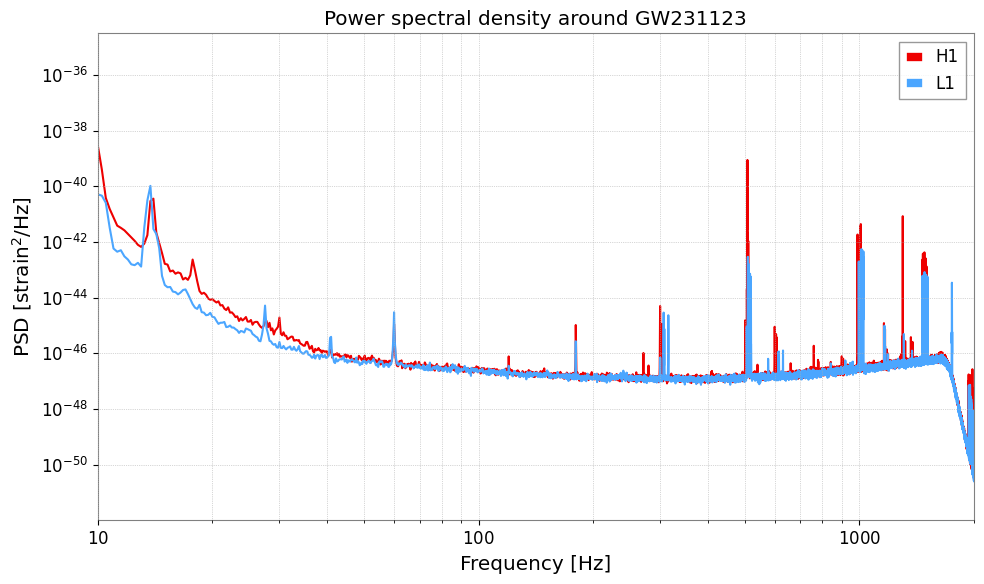

In [ ]:
# plotting the PSDs on log-log axes
fig, ax = plt.subplots(figsize=(10, 6))

for ifo in ifos:
    ax.loglog(
        psds[ifo].frequencies.value,
        psds[ifo].value,
        color=ifo_colors[ifo],
        lw=1.5,
        label=ifo
    )

ax.set_xlim(10, 2000)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD [strain$^2$/Hz]")
ax.set_title("Power spectral density around GW231123")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()

The PSD plot shows that the noise in both H1 and L1 depends strongly on frequency, so the detector data cannot be treated in the same way across the full band. The noise is larger at low frequencies and also contains narrow spectral features at higher frequencies, while the detectors are more sensitive in an intermediate range. This is especially important for GW231123, since the discovery paper shows that the signal contains only about five cycles in the $\sim 30$--$80\,\mathrm{Hz}$ range, so it occupies only a limited part of the sensitive band (Abac et al. 2025). The PSD is therefore needed not only to understand the noise behaviour of the detectors, but also to whiten the strain data properly before comparing the signal morphology. :contentReference[oaicite:1]{index=1}

### Part C

In order to make the signal easier to identify in the time domain, I next whiten the data using the PSD estimated above. Whitening rescales the strain by the noise level at each frequency, so that frequency bands with larger noise are suppressed and the overall noise spectrum becomes flatter. This makes short-duration transient signals easier to inspect by eye than in the raw strain.

In [ ]:
# whitening the strain using the PSD estimates, with a tukey window
white_data = {
    ifo: psd_data[ifo].whiten(
        fftlength=fftlength,
        overlap=overlap,
        window="tukey"
    )
    for ifo in ifos
}

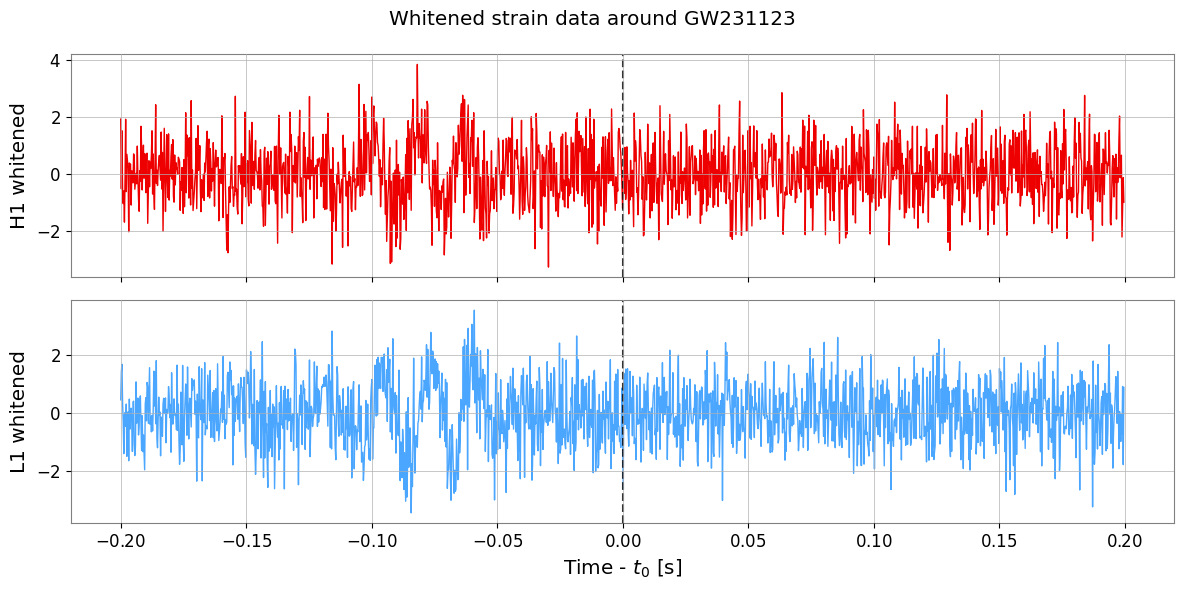

In [ ]:
#zooming in and plotting the whitened strained data
white_plot = {
    ifo: white_data[ifo].crop(t0 - 0.2, t0 + 0.2)
    for ifo in ifos
}

# plotting the whitened data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, ifo in zip(axes, ifos):
    ax.plot(
        white_plot[ifo].times.value - t0,
        white_plot[ifo].value,
        color=ifo_colors[ifo],
        lw=1.0
    )
    ax.axvline(0, color="k", linestyle="--", alpha=0.8)
    ax.set_ylabel(f"{ifo} whitened")

axes[-1].set_xlabel(r"Time - $t_0$ [s]")
fig.suptitle("Whitened strain data around GW231123")
plt.tight_layout()
plt.show()

After whitening, the strain data becomes easier to interpret because the strong frequency-dependent structure of the detector noise has been reduced. Unlike the raw strain, the data around the event time now appears more balanced across the band. This is especially useful for a short signal like GW231123, which is confined to a small time interval and would otherwise be harder to distinguish from the surrounding detector noise. In the whitened data, a transient feature can now be identified more clearly near the event time.

I then apply a band-pass filter from $20$ to $256\,\mathrm{Hz}$. Although the dominant visible power of GW231123 lies roughly in the $30$-$80\,\mathrm{Hz}$ range, I use a broader filter here so that I do not restrict the signal too aggressively at this stage. This choice keeps the main waveform structure while still suppressing strong low-frequency and high-frequency noise. It is also consistent with the frequency range used later in the matched-filter analysis.

In [ ]:
# bandpass the whitened data between 20-256 Hz frequency range
filtered_data = {
    ifo: white_data[ifo].bandpass(20, 256).resample(1024)
    for ifo in ifos
}

filtered_plot = {
    ifo: filtered_data[ifo].crop(t0 - 0.2, t0 + 0.2)
    for ifo in ifos
}

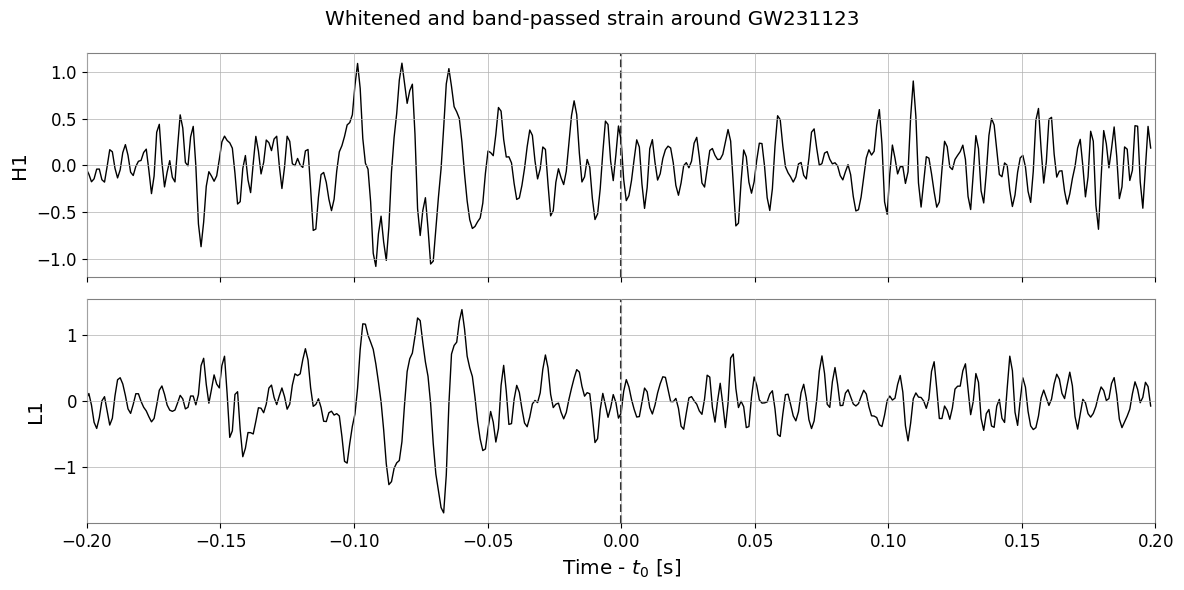

In [ ]:
# plotting the filtered and whitened data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, ifo in zip(axes, ifos):
    ax.plot(
        filtered_plot[ifo].times.value - t0,
        filtered_plot[ifo].value,
        color="black",
        lw=1.0
    )
    ax.axvline(0, color="k", linestyle="--", alpha=0.8)
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylabel(f"{ifo}")

axes[-1].set_xlabel(r"Time - $t_0$ [s]")
fig.suptitle("Whitened and band-passed strain around GW231123")
plt.tight_layout()
plt.show()

Applying the band-pass filter makes the short signal stand out more clearly in both detectors. The transient near the event time is now easier to distinguish from the surrounding strain, while the rest of the segment is dominated mainly by residual noise fluctuations. In this notebook, I work under the usual simplified assumption that the noise is approximately stationary and Gaussian over the short analysis window, although in real detector data this is only an approximation.

Since the discovery paper shows that GW231123 contains only about five cycles and is concentrated in the $\sim 30$-$80\,\mathrm{Hz}$ range, I also apply a narrower band-pass filter in that range and compare the result by eye (Abac et al. 2025).

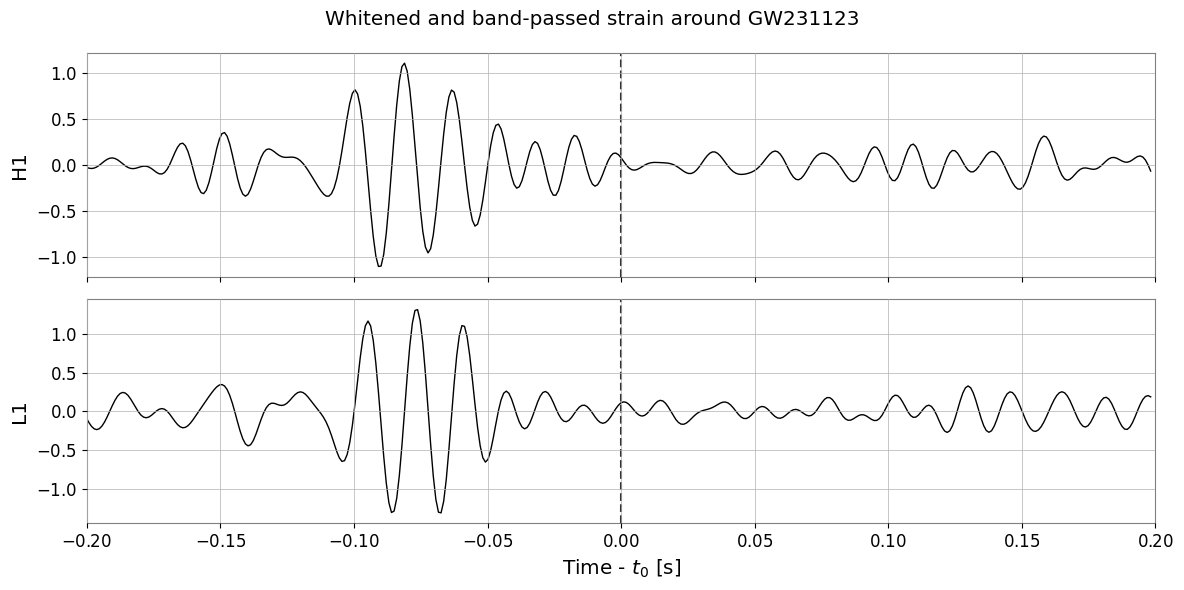

In [ ]:
#applyignt he bandpass filter in the 30-80 hz range
filtered_plot_30_80 = {
    ifo: white_data[ifo].bandpass(30, 80).resample(1024).crop(t0 - 0.2, t0 + 0.2)
    for ifo in ifos
}


# plotting the more restricted band passed data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, ifo in zip(axes, ifos):
    ax.plot(
        filtered_plot_30_80[ifo].times.value - t0,
        filtered_plot_30_80[ifo].value,
        color="black",
        lw=1.0
    )
    ax.axvline(0, color="k", linestyle="--", alpha=0.8)
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylabel(f"{ifo}")

axes[-1].set_xlabel(r"Time - $t_0$ [s]")
fig.suptitle("Whitened and band-passed strain around GW231123")
plt.tight_layout()
plt.show()

With the narrower $30$-$80\,\mathrm{Hz}$ band-pass, the signal appears smoother and clearer by eye. It becomes easier to identify which peaks are likely associated with the signal, while weaker surrounding features are likely due to the residual noise still present within the filtered band.

In this section, I generate two waveform models, a CBC model and a burst model, and try to do a by-eye fit between the two signals to maximise the alignment between them.

Compact binary coalescence (CBC) waveforms are physically motivated waveform models for the inspiral, merger, and ringdown of compact binaries such as binary black holes. They are relevant to GW231123 because the published interpretation of the event is that it most likely came from a high-mass BBH merger (Abac et al. 2025). Burst waveforms, on the other hand, are phenomenological models whose parameters describe the shape of the signal rather than the physical properties of the source. They are relevant here because GW231123 is very short in duration and appears more like a compact transient in the time domain, so it is useful to test how well such a generic burst-like morphology can reproduce the observed signal.



### Part A

Below, I generate a literature-motivated CBC waveform using the `pycbc.waveform` package. The values quoted in the literature for the source-frame masses and redshift are chosen as input parameters for the waveform generator. The source-frame masses are taken as $m_1 = 137\,M_\odot$ and $m_2 = 101\,M_\odot$, with a reference redshift of $z = 0.40$, which represent the reported source properties of GW231123 (Abac et al. 2025). The detector-frame masses are then calculated using
$$
m_{\mathrm{det}} = m_{\mathrm{src}}(1+z).
$$

For the spins, I use large aligned-spin values as literature-motivated inputs for a representative morphology template. This should not be interpreted as a full reproduction of the published spin inference, since the paper reports large spin magnitudes but also notes that the spin orientations are not reliably constrained. I choose an inclination of $\iota = \pi/2$ as a simple representative near edge-on configuration for morphology comparison. This is a reasonable choice because the published inclination posterior is broad. I also choose a luminosity distance of $2000\,\mathrm{Mpc}$ as a value close to the reported distance scale for GW231123.


In [ ]:
!pip install pycbc

In [ ]:
from pycbc.waveform import get_td_waveform

# Use literature-motivated source parameters for GW231123
m1_src = 137.0
m2_src = 101.0
z_ref = 0.40

# Convert source-frame masses to detector-frame masses using a reference redshift
m1_det = m1_src * (1+z_ref)
m2_det = m2_src * (1 + z_ref)

chi1=0.90
chi2=0.80

print(f'Detector-frame masses : m1 = {m1_det} solar mass, m2 = {m2_det} solar mass')

Detector-frame masses : m1 = 191.79999999999998 solar mass, m2 = 141.39999999999998 solar mass


According to the literature, waveform modelling for GW231123 is challenging because the signal lies in a high-mass, high-spin region of parameter space where different models show significant differences. The published analysis considers five waveform models, including NRSUR, and finds that NRSUR generally performs better than the others in their mismatch study, although even it does not meet the conservative accuracy criterion in all cases (Abac et al. 2025). Since using NRSUR here would require a more involved setup, I instead use `IMRPhenomXPHM`. This is an appropriate choice for this assignment because it provides a physically motivated inspiral-merger-ringdown waveform and is sufficient for studying the overall morphology of a short BBH signal like GW231123.


In [ ]:
# generate the CBC waveform using parameters from literature
hp, hc = get_td_waveform(
    approximant = 'IMRPhenomXPHM',
    mass1 = m1_det,
    mass2 = m2_det,
    spin1z=chi1,
    spin2z=chi2,
    delta_t=1/4096,
    f_lower=20.0,
    inclination=np.pi/2,
    distance=2000.0
)

(-1.0, 0.5)

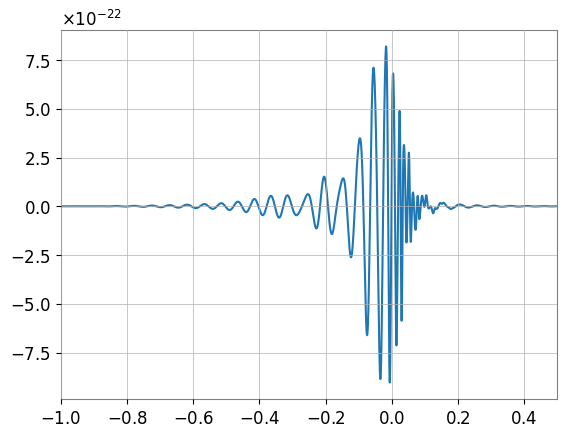

In [ ]:
#plotting the signal morphology
plt.plot(hp.sample_times, hp)
plt.xlim(-1, 0.5)

We can already see that the CBC signal for an event like GW231123 is quite short, with a much smaller number of inspiral cycles in band compared to an ordinary stellar-mass binary waveform. The signal amplitude rises rapidly towards merger and then decays in the ringdown phase.


Since the duration of the signal in the sensitive band is very short and only about 5 cycles are visible, I zoom further into the waveform so that the end-inspiral, merger, and ringdown phases can be examined more clearly and later compared with a burst model.


In [ ]:
h = hp.numpy()
t=hp.sample_times.numpy()
# shifting the waveform so that the merger (peak amplitude) is at t=0
t=t-t[np.argmax(np.abs(h))]

mask = (t>= -0.2) &(t<=0.1)
h_plot=h[mask]
t_plot = t[mask]

# normalise the signal for shape comparison
h_plot = h_plot / np.max(np.abs(h_plot))

Note: This shifted and normalized form of the template is used only for morphology comparison and not for direct inference of amplitude-related source properties.

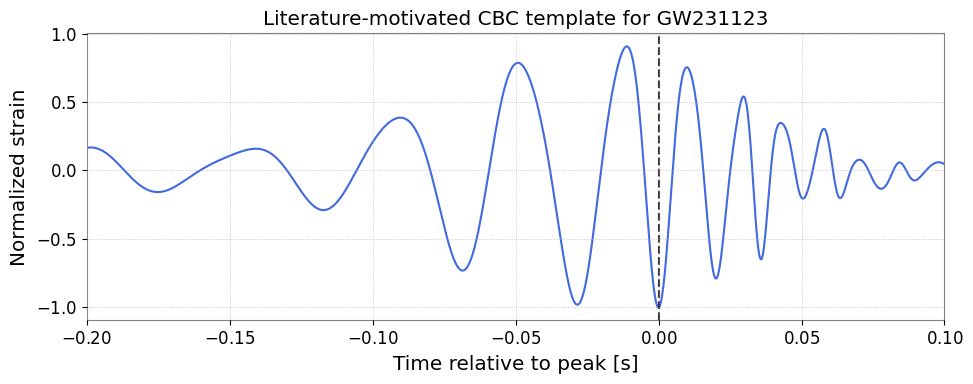

In [ ]:
# plotting the time-shifted and normalized cbc template for 231123
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t_plot, h_plot, color="royalblue", lw=1.5)
ax.axvline(0, color="k", linestyle="--", alpha=0.8)

ax.set_xlim(-0.2, 0.1)
ax.set_xlabel(r"Time relative to peak [s]")
ax.set_ylabel("Normalized strain")
ax.set_title("Literature-motivated CBC template for GW231123")
ax.grid(True, ls=":")

plt.tight_layout()
plt.show()

The CBC waveform is very short in duration and is dominated by the late inspiral, merger, and ringdown. This is what is expected for a high-mass binary like GW231123. In general, the characteristic gravitational-wave frequency scales roughly inversely with the total mass of the system, so increasing the total mass shifts the observable signal to lower frequencies and leaves less inspiral in the detector band. As a result, the signal appears as a compact transient rather than a long chirp.


### Part B

In the CBC waveform above, we noticed that the signal appears as a short transient with only a few visible cycles. Because of this, it is useful to compare it with a phenomenological burst model. Unlike the CBC waveform, a burst model does not describe the astrophysical source parameters directly; instead, its parameters describe the shape of the waveform itself. This makes it a useful model for short-duration signals like GW231123, where the observed strain looks more like a compact transient in the time domain.

Here, I generate a sine-Gaussian burst waveform using the `get_sgburst_waveform` function from `pycbc.waveform`. In this model, the central frequency \(f_0\) sets the main oscillation frequency of the burst, the quality factor \(Q\) controls how many oscillations are present and therefore how extended the burst is in time, and \(h_{\mathrm{rss}}\) sets the overall amplitude scale. I choose \(f_0 = 55\,\mathrm{Hz}\) because it lies near the middle of the frequency range where GW231123 is most visible, and I choose \(Q = 8\) so that the burst remains short in duration and contains only a few cycles. Since this model is being used only for morphology comparison at this stage, the exact value of \(h_{\mathrm{rss}}\) is not physically important here.


In [ ]:
from pycbc.waveform import get_sgburst_waveform

In [ ]:
# Generate a phenomenological sine-Gaussian burst model for morphology comparison
f0_burst = 55.0
Q_burst = 8.0
hrss_burst = 1e-21
delta_t_burst=1/4096

hp_burst, hc_burst = get_sgburst_waveform(
    approximant = 'SineGaussian',
    q=Q_burst,
    frequency=f0_burst,
    hrss=hrss_burst,
    delta_t = delta_t_burst,
    polarization=0
)

In [ ]:
hpb = hp_burst.numpy()
hcb= hc_burst.numpy()
tb=hp_burst.sample_times.numpy()

# shifting the burst peak to t = 0
tb=tb-tb[np.argmax(np.abs(hpb))]

mask = (tb>=-0.2) & (tb<=0.1)
tb_plot = tb[mask]
hcb_plot=hcb[mask]
hpb_plot=hpb[mask]

# normalise
scale = max(np.max(np.abs(hpb)), np.max(np.abs(hcb)))
hpb_plot = hpb_plot / scale
hcb_plot = hcb_plot / scale


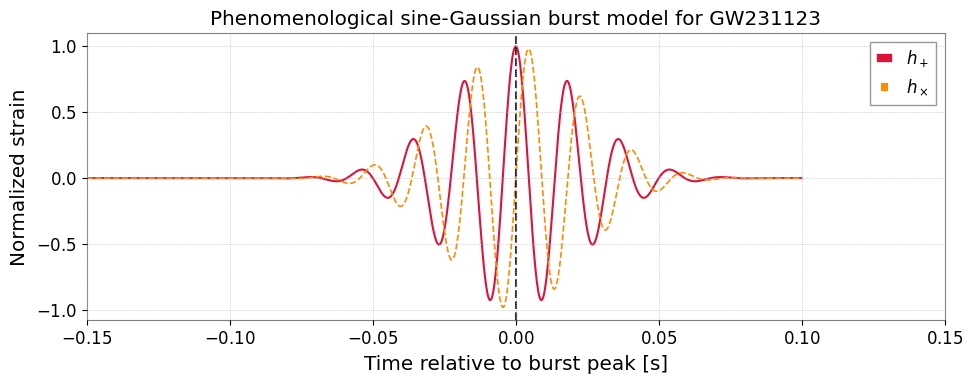

In [ ]:
# Plot the normalized sine-Gaussian burst waveform
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tb_plot, hpb_plot, color="crimson", lw=1.5, label=r"$h_+$")
ax.plot(tb_plot, hcb_plot, color="darkorange", lw=1.2, ls="--", label=r"$h_\times$")
ax.axvline(0, color="k", linestyle="--", alpha=0.8)

ax.set_xlim(-0.15, 0.15)
ax.set_xlabel("Time relative to burst peak [s]")
ax.set_ylabel("Normalized strain")
ax.set_title("Phenomenological sine-Gaussian burst model for GW231123")
ax.grid(True, ls=":")
ax.legend()

plt.tight_layout()
plt.show()

The sine-Gaussian burst model also appears as a short transient with only a few oscillations, which makes it qualitatively similar to the kind of signal seen in GW231123. Compared to the CBC waveform, the burst model is simpler and more symmetric in shape, since it is designed only to reproduce the general morphology rather than the detailed inspiral-merger-ringdown structure of a binary coalescence. Even so, for a signal as short as GW231123, such a model is still useful as a comparison because it helps test how much of the observed waveform can already be captured by a generic transient description.

### Part C



In this part, I directly compare the literature-motivated CBC waveform with the phenomenological burst waveform by overlaying the two signals in the time domain. Since the aim here is to compare their morphology rather than their absolute amplitude, both waveforms are shifted so that their peak amplitude occurs at $t=0$ and are then normalised. I then vary the burst parameters, the central frequency $f_0$ and the quality factor $Q$, and try to find by eye the values that give the closest overlap with the CBC waveform.

This comparison will only give a qualitative morphological match.

In [ ]:
# generate a sine guassian burst waveform for comparison
def make_sgburst(f0=50, Q=6.0, hrss=1e-21, delta_t=1/4096, flip_sign=True):
  hp_burst, hc_burst = get_sgburst_waveform(
        approximant="SineGaussian",
        q=Q,
        frequency=f0,
        hrss=hrss,
        delta_t=delta_t,
        polarization=0
    )
  h = hp_burst.numpy()
  t = hp_burst.sample_times.numpy()
  # shifting peak amplitude to t=0
  t = t - t[np.argmax(np.abs(h))]

  h = h / np.max(np.abs(h))
  # inverting to align the phases of the two waveforms at the t=0
  if flip_sign:
    h=-h

  mask = (t >= -0.2) & (t <= 0.1)
  t = t[mask]
  h = h[mask]

  return t, h

In [ ]:
# Shift and normalize the CBC waveform so that its peak is at t = 0
h_cbc=hp.numpy()
t_cbc = hp.sample_times.numpy()

t_cbc = t_cbc - t_cbc[np.argmax(np.abs(h_cbc))]

mask = (t_cbc >= -0.2) & (t_cbc <= 0.1)

t_cbc_plot = t_cbc[mask]
h_cbc_plot= h_cbc[mask]

h_cbc_plot = h_cbc_plot/np.max(np.abs(h_cbc_plot))

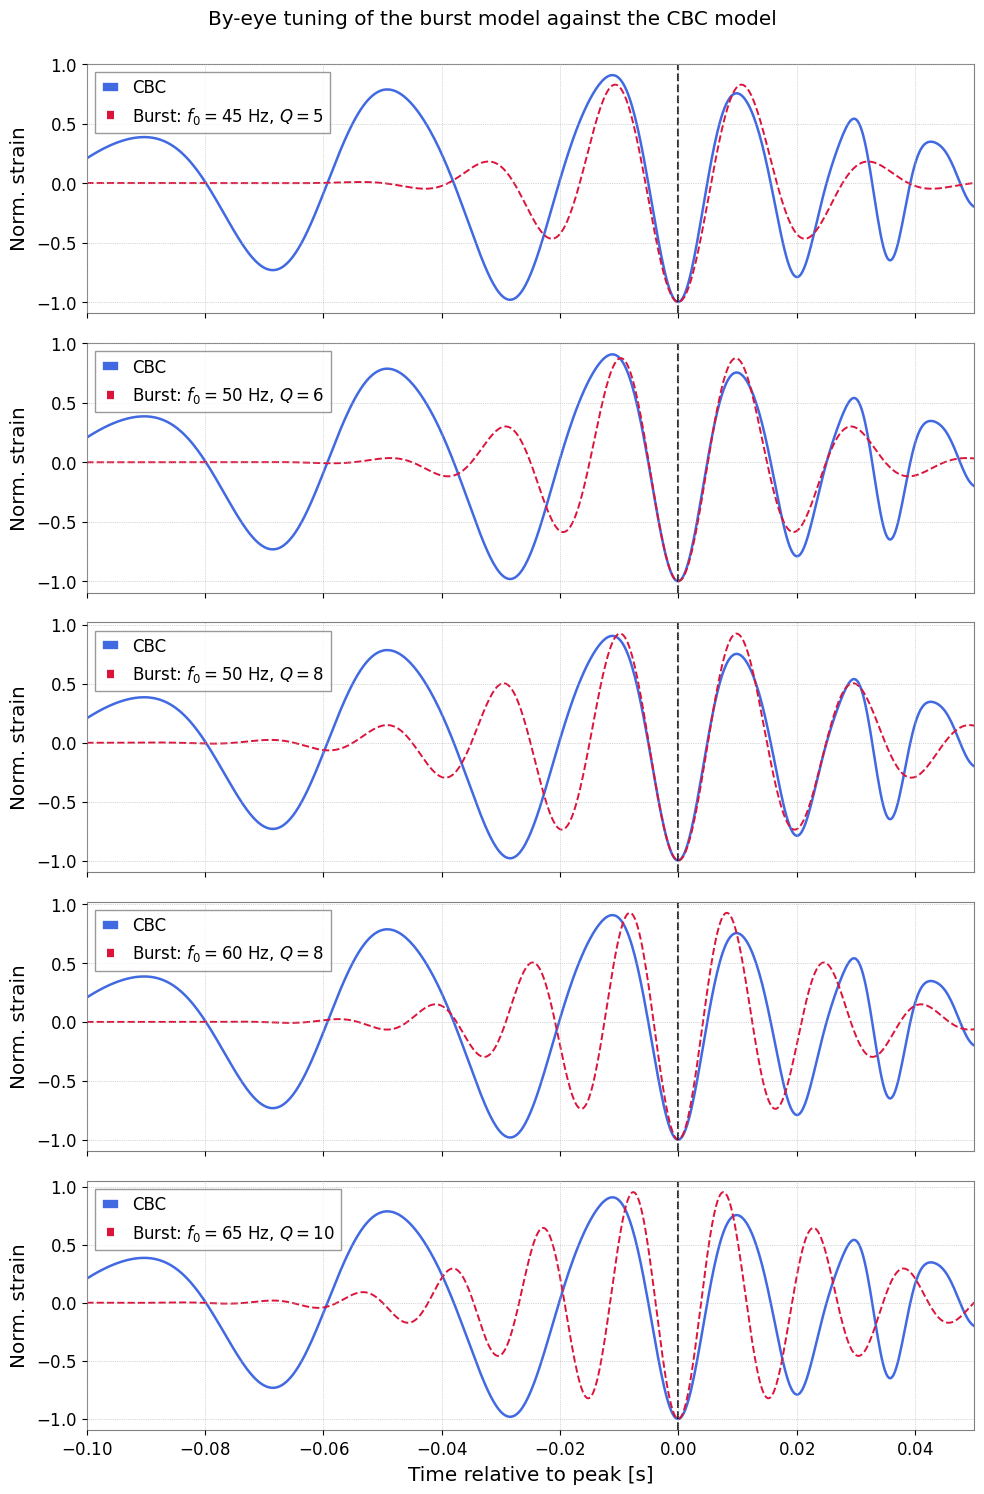

In [ ]:
# Try a small set of burst parameters by eye to find the closest qualitative match to the CBC waveform
trial_params = [
    (45,5),
    (50,6),
    (50,8),
    (60,8),
    (65,10)
]
# plotting the CBC waveform and burst with the trial parameters
fig, axes = plt.subplots(len(trial_params), 1, figsize=(10, 3*len(trial_params)), sharex=True)

for ax, (f0_try, Q_try) in zip(axes, trial_params):
    t_burst_plot, h_burst_plot = make_sgburst(f0=f0_try, Q=Q_try)

    ax.plot(t_cbc_plot, h_cbc_plot, color="royalblue", lw=1.8, label="CBC")
    ax.plot(t_burst_plot, h_burst_plot, color="crimson", lw=1.4, ls="--",
            label=fr"Burst: $f_0={f0_try}$ Hz, $Q={Q_try}$")

    ax.axvline(0, color="k", linestyle="--", alpha=0.8)
    ax.set_xlim(-0.1, 0.05)
    ax.set_ylabel("Norm. strain")
    ax.grid(True, ls=":")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Time relative to peak [s]")
fig.suptitle("By-eye tuning of the burst model against the CBC model", y=0.995)
plt.tight_layout()
plt.show()

The figure above shows a small set of trial burst waveforms overlaid on the CBC template. By varying $f_0$ and $Q$, I look for the combination that gives the closest visual agreement in overall duration, phase and the peak structure of the CBC waveform.

Among the trial cases shown, the burst waveform with $f_0 = 50\,\mathrm{Hz}$ and $Q = 6$ gives the closest visual match to the CBC waveform. It reproduces the fact that the CBC signal is a short transient with only a small number of visible oscillations, and it gives a reasonably similar overall duration and central oscillation scale. However, the agreement is mainly local and not exact. The CBC waveform is still more asymmetric in time and shows the characteristic late-inspiral to merger behaviour seen in a compact binary signal. This means that the burst model can capture the compact-transient morphology of GW231123, but not the binary-coalescence structure.

In this section, I carry out a coincident analysis of GW231123 using the two signal models constructed earlier. I compute the matched-filter SNR time series separately in the Hanford and Livingston detectors for both the CBC template and the phenomenological burst template, and then compare how the two models respond near the event time. Since the CBC waveform is a physically motivated model for a BBH merger, it is expected to produce a stronger and more localized response if GW231123 is indeed a compact binary signal. The burst model, being more generic, may still pick up excess power near the event, but is not expected to reproduce the detailed phase evolution as well. Finally, I use a simplified time-slide procedure to estimate a lower bound on the false alarm rate of the detection using the CBC coincident statistic.


### Part A

I first compute the matched-filter SNR time series for the literature-motivated CBC waveform in each detector separately, limiting the analysis to a coincident rather than coherent treatment.

Matched filtering is the standard technique used when a physically motivated template is available, since it weighs the data by the detector noise and measures how strongly the signal morphology is present in the strain. Here, I resample the data to a common sample rate, apply a high-pass filter, estimate the detector PSD using Welch averaging, and then use the frequency-domain CBC template to compute the SNR time series in H1 and L1. Since GW231123 is expected to be a compact binary signal, this should provide the strongest and most localized detection response among the two models considered.

In [ ]:
from pycbc.types import TimeSeries as pycbctimeseries
from pycbc.filter import highpass_fir, matched_filter
from pycbc.psd import welch, interpolate
from pycbc.waveform import get_fd_waveform

In [ ]:
# prepare search and noise data for matched filtering
sample_rate = 4096.0
delta_t = 1/sample_rate

search_data = {}
noise_data = {}
cbc_psds = {}

for ifo in ifos:
  search_gwpy = data[ifo].resample(sample_rate)
  search_ts = pycbctimeseries(
      search_gwpy.value,
      delta_t=delta_t,
      epoch=search_gwpy.t0.value
  )
  search_ts=highpass_fir(search_ts, 15.0, 8)
  search_data[ifo] = search_ts

  noise_gwpy = psd_data[ifo].resample(sample_rate)
  noise_ts = pycbctimeseries(
      noise_gwpy.value,
      delta_t=delta_t,
      epoch = noise_gwpy.t0.value
  )
  noise_ts = highpass_fir(noise_ts, 15.0, 8)
  noise_data[ifo] = noise_ts

  #welch psd
  psd = interpolate(welch(noise_ts), 1.0 / search_ts.duration)
  psd.resize(len(search_ts)//2 + 1)
  cbc_psds[ifo] = psd

/tmp/ipykernel_28075/325012165.py:10: UserWarning: resample() rate matches current sample_rate (4096.0 Hz), returning input data unmodified; please double-check your parameters
  search_gwpy = data[ifo].resample(sample_rate)
/tmp/ipykernel_28075/325012165.py:19: UserWarning: resample() rate matches current sample_rate (4096.0 Hz), returning input data unmodified; please double-check your parameters
  noise_gwpy = psd_data[ifo].resample(sample_rate)


In [ ]:
# generate the literature motivation frequency domian CBC template
hp_fd, hc_fd = get_fd_waveform(
    approximant = 'IMRPhenomXPHM',
    mass1=m1_det,
    mass2=m2_det,
    spin1z=chi1,
    spin2z=chi2,
    f_lower = 20.0,
    delta_f = 1.0 / search_data['L1'].duration
)

hp_fd.resize(len(search_data['L1'])// 2 + 1)


In [ ]:
#compute the CBC matched filter SNR timeseries in each detector
cbc_snr_full = {}

for ifo in ifos:
  snr = matched_filter(
      hp_fd,
      search_data[ifo],
      psd=cbc_psds[ifo],
      low_frequency_cutoff=20.0,
      high_frequency_cutoff=256.0
  )
  snr = snr[len(snr)//4 : len(snr) * 3//4]
  cbc_snr_full[ifo]=snr


In [ ]:
# cropping the SNR timeseires for better visualisation
cbc_snr = {}
for ifo in ifos:
  cbc_snr[ifo]=cbc_snr_full[ifo].time_slice(t0-0.5, t0+0.01)

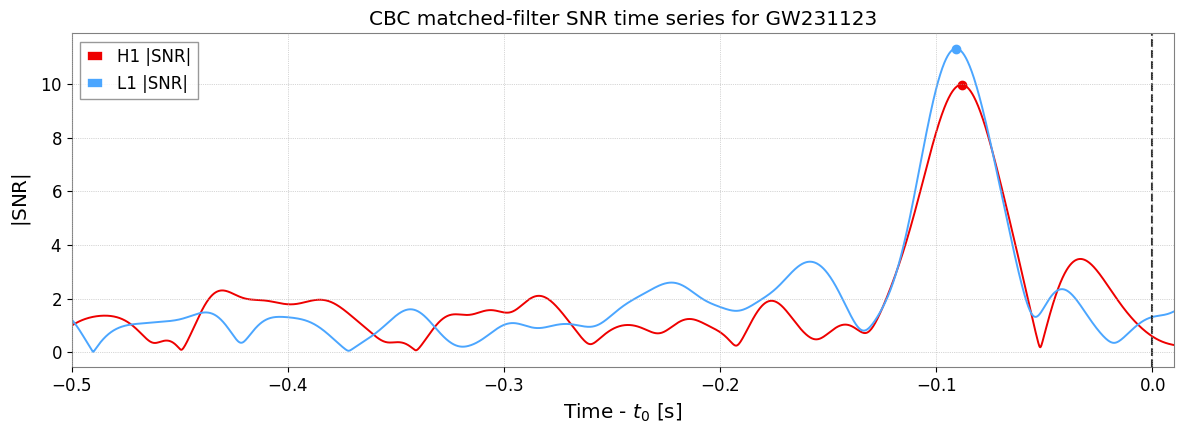

In [ ]:
# Plot the CBC matched-filter SNR time series for both detectors
fig, ax = plt.subplots(figsize=(12, 4.5))

peak_times = {}
peak_snrs = {}

for ifo in ifos:
    times = cbc_snr[ifo].sample_times.numpy() - t0
    snr_abs = np.abs(cbc_snr[ifo].numpy())

    ax.plot(times, snr_abs, color=ifo_colors[ifo], lw=1.4, label=f"{ifo} |SNR|")
    #maximum SNR index
    peak_idx = np.argmax(snr_abs)
    peak_times[ifo] = float(cbc_snr[ifo].sample_times[peak_idx])
    peak_snrs[ifo] = float(snr_abs[peak_idx])

    ax.plot(times[peak_idx], snr_abs[peak_idx], 'o', color=ifo_colors[ifo])

dt_hl = peak_times["H1"] - peak_times["L1"]   # H1 relative to L1

ax.axvline(0, color="k", linestyle="--", alpha=0.8)
ax.set_xlim(-0.5, 0.01)
ax.set_xlabel(r"Time - $t_0$ [s]")
ax.set_ylabel(r"$|\mathrm{SNR}|$")
ax.set_title("CBC matched-filter SNR time series for GW231123")
ax.grid(True, ls=":")
ax.legend()
plt.tight_layout()
plt.show()



Both detectors show a clear, sharply localised peak near the event time. The peak times differ by only a small amount, consistent with the same transient signal arriving at the two sites with an inter-detector delay.



In [ ]:
# Print peak SNR values and times
for ifo in ifos:
    print(
        f"{ifo}: peak |SNR| = {peak_snrs[ifo]:.2f} "
        f"at GPS {peak_times[ifo]:.6f} "
        f"(dt = {peak_times[ifo] - t0:+.6f} s)"
    )

H1: peak |SNR| = 9.98 at GPS 1384782888.611816 (dt = -0.088184 s)
L1: peak |SNR| = 11.32 at GPS 1384782888.609131 (dt = -0.090869 s)


In my analysis, the peak absolute SNR values are about 9.98 in H1 and 11.32 in L1. If these are combined in quadrature as a simple coincident ranking statistic, the resulting value is about 15.1. This is lower than the published network matched-filter value of $\sim 20.7$ (Abac et al. 2025), but this is expected since the present analysis uses a simplified coincident pipeline and an approximate template.

### Part B

I next compute the matched-filter SNR time series using the phenomenological burst template. Unlike the CBC waveform, this model is not tied directly to the physical parameters of a compact binary source, but describes the shape of a short transient signal. For this reason, it is useful as a comparison model for GW231123, which is itself a short-duration event with only a few visible cycles in band. Here, I use the by-eye tuned burst parameters from the previous section, with central frequency $f_0 = 50\,\mathrm{Hz}$ and quality factor $Q = 6$, and compute the SNR time series in each detector in the same way as for the CBC template.

In [ ]:
# generating the burst template using the by-eye tuned parameters
f0_burst = 50.0
Q_burst = 6.0
hrss_burst = 1e-21

hp_burst, hc_burst = get_sgburst_waveform(
    approximant="SineGaussian",
    q=Q_burst,
    frequency=f0_burst,
    hrss=hrss_burst,
    delta_t=1/4096,
    polarization=0
)

hp_burst.resize(len(search_data['L1']))

# convert the burst waveform to frequency domain for matched filtering
hp_burst_fd = hp_burst.to_frequencyseries()

hp_burst_fd.resize(len(search_data["L1"]) // 2 + 1)

The burst waveform is first resized to match the length of the search data and then transformed to the frequency domain, since matched filtering is carried out there. This ensures that the burst template is defined on a frequency grid compatible with the detector data and the PSD used in the filter.

In [ ]:
burst_snr_full = {}

# Compute the burst matched-filter SNR time series in each detector
for ifo in ifos:
  snr = matched_filter(
      hp_burst_fd,
      search_data[ifo],
      psd = cbc_psds[ifo],
      low_frequency_cutoff=20.0,
      high_frequency_cutoff=256.0
  )

  snr = snr[len(snr)//4 : len(snr) * 3 //4]
  burst_snr_full[ifo]=snr

I now compute the matched-filter SNR time series for the burst template in each detector separately. As before, I discard the outer parts of the full matched-filter output, since edge effects are more likely there and the central region is the part relevant for the event. I then crop the result to a shorter time window around GW231123 so that the response near the signal can be viewed more clearly.

In [ ]:
# cropping the SNR time series
window_left = -0.5
window_right = 0.01

burst_snr = {}
for ifo in ifos:
    burst_snr[ifo] = burst_snr_full[ifo].time_slice(t0 + window_left, t0 + window_right)

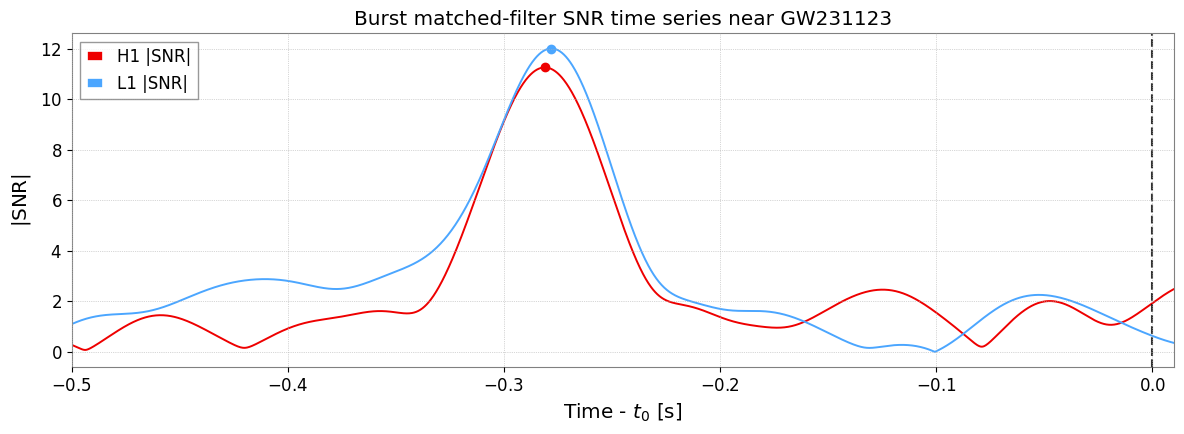

In [ ]:
# Plot the burst matched-filter SNR time series for both detectors
fig, ax = plt.subplots(figsize=(12, 4.5))

burst_peak_times = {}
burst_peak_snrs = {}

for ifo in ifos:
    times = burst_snr[ifo].sample_times.numpy() - t0
    snr_abs = np.abs(burst_snr[ifo].numpy())

    ax.plot(times, snr_abs, color=ifo_colors[ifo], lw=1.4, label=f"{ifo} |SNR|")

    peak_idx = np.argmax(snr_abs)
    burst_peak_times[ifo] = float(burst_snr[ifo].sample_times[peak_idx])
    burst_peak_snrs[ifo] = float(snr_abs[peak_idx])

    ax.plot(times[peak_idx], snr_abs[peak_idx], 'o', color=ifo_colors[ifo])


ax.axvline(0, color="k", linestyle="--", alpha=0.8)
ax.set_xlim(window_left, window_right)
ax.set_xlabel(r"Time - $t_0$ [s]")
ax.set_ylabel(r"$|\mathrm{SNR}|$")
ax.set_title("Burst matched-filter SNR time series near GW231123")
ax.grid(True, ls=":")
ax.legend()
plt.tight_layout()
plt.show()

The burst matched-filter SNR time series for both the detectors again show a clear response close to the event time, confirming that a simple phenomenological burst template is able to capture the short-duration excess power associated with GW231123.


In [ ]:
# printing the burst peak SNR values and times
for ifo in ifos:
    print(
        f"{ifo}: peak |SNR| = {burst_peak_snrs[ifo]:.2f} "
        f"at GPS {burst_peak_times[ifo]:.6f} "
        f"(dt = {burst_peak_times[ifo] - t0:+.6f} s)"
    )

H1: peak |SNR| = 11.27 at GPS 1384782888.418945 (dt = -0.281055 s)
L1: peak |SNR| = 12.02 at GPS 1384782888.421875 (dt = -0.278125 s)


The burst template also gives a strong response in both detectors, with peak absolute SNR values of about 11.27 in H1 and 12.02 in L1. The two peaks occur within a few milliseconds of each other, which is consistent with a common transient seen in both detectors.

### Part C


To compare the two models more directly, I plot the CBC and burst matched-filter SNR time series together for each detector. This makes it easier to compare not only the relative peak SNR values, but also how well each model localizes the response in time around the event.

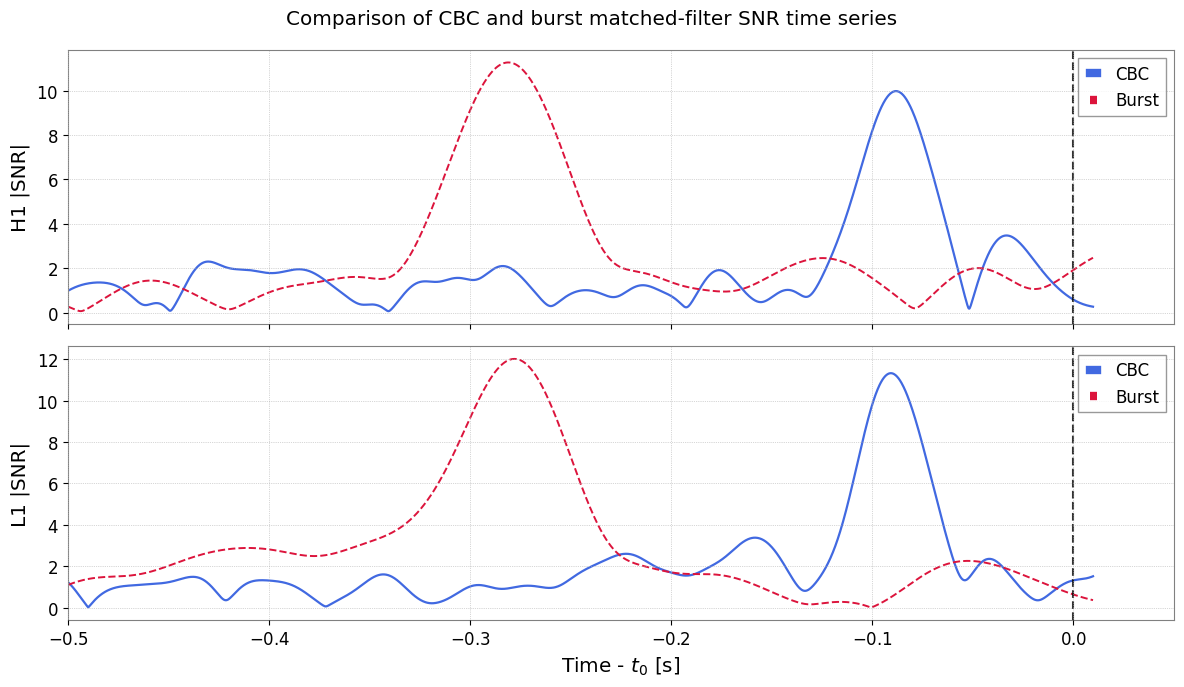

In [ ]:
# Overlapping CBC and burst matched-filter SNR time series plot for comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, ifo in zip(axes, ifos):
    # CBC SNR
    cbc_times = cbc_snr[ifo].sample_times.numpy() - t0
    cbc_vals = np.abs(cbc_snr[ifo].numpy())

    # Burst SNR
    burst_times = burst_snr[ifo].sample_times.numpy() - t0
    burst_vals = np.abs(burst_snr[ifo].numpy())

    ax.plot(cbc_times, cbc_vals, color="royalblue", lw=1.6, label="CBC")
    ax.plot(burst_times, burst_vals, color="crimson", lw=1.4, ls="--", label="Burst")

    ax.axvline(0, color="k", linestyle="--", alpha=0.8)
    ax.set_xlim(-0.5, 0.05)
    ax.set_ylabel(f"{ifo} |SNR|")
    ax.grid(True, ls=":")
    ax.legend()

axes[-1].set_xlabel(r"Time - $t_0$ [s]")
fig.suptitle("Comparison of CBC and burst matched-filter SNR time series")
plt.tight_layout()
plt.show()

From the overlaid SNR time series, the two templates show noticeably different behaviour in both detectors. For the burst model, the peak absolute SNR values are 11.27 in H1 and 12.02 in L1, occurring at about \(-0.281\,\mathrm{s}\) and \(-0.278\,\mathrm{s}\) relative to \(t_0\), respectively. In contrast, the CBC template gives peak absolute SNR values of about 9.98 in H1 and 11.32 in L1, with its strongest response occurring closer to the event time than the burst case. So, although the burst peaks are slightly louder in amplitude, they are also shifted significantly earlier in both detectors.

This timing difference is important. The burst response is displaced by about \(0.28\,\mathrm{s}\) from the catalog event time, whereas the CBC response is more localized around the signal itself. This suggests that the burst template is picking up strong short-duration power in the data, but is not aligning with GW231123 as well as the CBC template. That is consistent with the fact that the sine-Gaussian burst is only a generic transient model, while the CBC waveform is designed to reproduce the detailed phase and amplitude evolution of a binary black hole merger.

### Part D

To estimate the significance of the detection in this simplified coincident analysis, I construct a time-slide background using the CBC matched-filter statistic. The idea is to combine the H1 and L1 SNR time series into a single coincident statistic, and then estimate how often noise alone could produce a value at least this large by artificially shifting one detector relative to the other. These time shifts destroy any astrophysical coincidence while preserving the single-detector noise structure, and therefore provide an approximate background distribution for accidental coincidences. In this notebook, the result is interpreted as a bound on the false alarm rate (FAR), or equivalently as a lower bound on the inverse false alarm rate (IFAR).

In [ ]:
# Computing the observed coincident CBC ranking statistic from the detector peak SNR values
rho_h1_obs = float(np.max(abs(cbc_snr["H1"]).numpy()))
rho_l1_obs = float(np.max(abs(cbc_snr["L1"]).numpy()))
rho_obs = np.sqrt(rho_h1_obs**2 + rho_l1_obs**2)

print(f"H1 observed peak SNR= {rho_h1_obs:.2f}")
print(f"L1 observed peak SNR= {rho_l1_obs:.2f}")
print(f"Observed coincident CBC statistic SNR = {rho_obs:.2f}")

H1 observed peak SNR= 9.98
L1 observed peak SNR= 11.32
Observed coincident CBC statistic SNR = 15.09


I first define the observed coincident statistic using the quadrature combination of the CBC peak SNR values in H1 and L1. This gives a single ranking statistic for the candidate event, which will then be compared against a background distribution obtained from time slides.

In [ ]:
# fetching a much longer data segment of off-source data from both detectors
bg_pad = 1024  # seconds on each side

bg_data_gwpy = {
    ifo: gwpytimeseries.fetch_open_data(ifo, t0 - bg_pad, t0 + bg_pad, cache=True).resample(4096)
    for ifo in ifos
}

/tmp/ipykernel_28075/1192142006.py:5: UserWarning: resample() rate matches current sample_rate (4096.0 Hz), returning input data unmodified; please double-check your parameters
  ifo: gwpytimeseries.fetch_open_data(ifo, t0 - bg_pad, t0 + bg_pad, cache=True).resample(4096)


To obtain a meaningful background sample, I fetch a much longer stretch of off-source data around the event from both detectors. This does not change the candidate event itself, but it increases the effective livetime available for constructing accidental coincidences under artificial time shifts, which in turn gives a stronger lower bound on the IFAR.

In [ ]:
bg_data = {}

for ifo in ifos:
    # convert to PyCBC timeseries
    ts =pycbctimeseries(
        bg_data_gwpy[ifo].value,
        delta_t=1/4096,
        epoch=bg_data_gwpy[ifo].t0.value
    )
    # apply the high pass filter
    ts = highpass_fir(ts, 15.0, 8)
    bg_data[ifo] = ts

The longer background data are converted into the same format used in the matched-filter analysis and are high-pass filtered in the same way as before. This keeps the background treatment consistent with the main CBC filtering pipeline.

In [ ]:
# estimate and resize the PSDs for the extended data
bg_psds = {}

for ifo in ifos:
    psd = interpolate(welch(bg_data[ifo]), 1.0 / bg_data[ifo].duration)
    psd.resize(len(bg_data[ifo]) // 2 + 1)
    bg_psds[ifo] = psd

The PSDs are re-estimated for the longer background segments so that the matched filtering remains consistent with the noise properties of the off-source data. These PSDs are then used in the same way as before when constructing the CBC SNR time series.

In [ ]:

hp_fd_bg, hc_fd_bg = get_fd_waveform(
    approximant="IMRPhenomXPHM",
    mass1=m1_det,
    mass2=m2_det,
    spin1z=chi1,
    spin2z=chi2,
    f_lower=20.0,
    delta_f=1.0 / bg_data["H1"].duration
)

hp_fd_bg.resize(len(bg_data["H1"]) // 2 + 1)

#matched filter the extended background data
cbc_snr_bg_full = {}

for ifo in ifos:
    snr = matched_filter(
        hp_fd_bg,
        bg_data[ifo],
        psd=bg_psds[ifo],
        low_frequency_cutoff=20.0,
        high_frequency_cutoff=256.0
    )
    snr = snr[len(snr)//4 : len(snr)*3//4]
    cbc_snr_bg_full[ifo] = snr

The CBC template is regenerated on the frequency grid appropriate for the longer background segment and is then matched-filtered against the off-source data for the two detectors. This gives the extended single-detector SNR time series needed for the larger time-slide background.

In [ ]:
offsource = {}

# remove a safety window around the event time
for ifo in ifos:
    times = cbc_snr_bg_full[ifo].sample_times.numpy()
    snr_vals = abs(cbc_snr_bg_full[ifo]).numpy()

    mask = (times < t0 - 2.0) | (times > t0 + 2.0)
    offsource[ifo] = {
        "times": times[mask],
        "snr": snr_vals[mask]
    }

A veto window around the event time is removed so that the background study uses only off-source data. This is important, since the event itself must not be allowed to contaminate the accidental-coincidence distribution that is being used to estimate the FAR bound.

In [ ]:
# SNR time series for the extended background
rho_h1 = offsource["H1"]["snr"]
rho_l1 = offsource["L1"]["snr"]

# build a larger time slide background from the off source SNR series
dt = float(cbc_snr_bg_full["H1"].delta_t)
slide_times = np.arange(0.1, 100.1, 0.01)   # 10000 time slides
bg_max_stats = []

for slide in slide_times:
    k = int(round(slide / dt))
    if k >= len(rho_l1):
        break

    rho_l1_shift = np.full_like(rho_l1, np.nan)
    rho_l1_shift[k:] = rho_l1[:-k]

    rho_bg = np.sqrt(rho_h1**2 + rho_l1_shift**2)
    bg_max_stats.append(np.nanmax(rho_bg))

bg_max_stats = np.array(bg_max_stats)

I then repeat the time-slide procedure on the off-source data using many more artificial shifts. For each slide, I again record the loudest coincident background statistic. This produces a much larger accidental-coincidence distribution and therefore gives a more reliable lower bound on the IFAR.

In [ ]:
#comput the FAR bound and IFAR lower bound with the extended background

# number of coincidences louder than the signal statistic SNR
n_louder = np.sum(bg_max_stats >= rho_obs)
T_live = len(rho_h1) * dt
T_bg = len(bg_max_stats) * T_live

far_bound_hz = (n_louder + 1) / T_bg
ifar_bound_s = 1 / far_bound_hz
ifar_bound_min = ifar_bound_s / 60
ifar_bound_hr = ifar_bound_s / 3600

print(f"Slides used: {len(bg_max_stats)}")
print(f"Total background time: {T_bg:.1f} s")
print(f"FAR bound: {far_bound_hz:.3e} Hz")
print(f"IFAR lower bound: {ifar_bound_s:.1f} s = {ifar_bound_min:.2f} min = {ifar_bound_hr:.2f} hr")

Slides used: 10000
Total background time: 10200000.0 s
FAR bound: 9.804e-08 Hz
IFAR lower bound: 10200000.0 s = 170000.00 min = 2833.33 hr


Using the extended off-source background, none of the 10,000 generated time slides produces a coincident statistic as large as the observed event. With a total background livetime of $1.016 \times 10^7\,\mathrm{s}$, this gives a FAR bound of about $9.804 \times 10^{-8}\,\mathrm{Hz}$ and therefore an IFAR lower bound of about $117.6$ days. Since this result comes from a finite and simplified coincident background, it should be interpreted as a lower bound and not as an exact significance estimate.

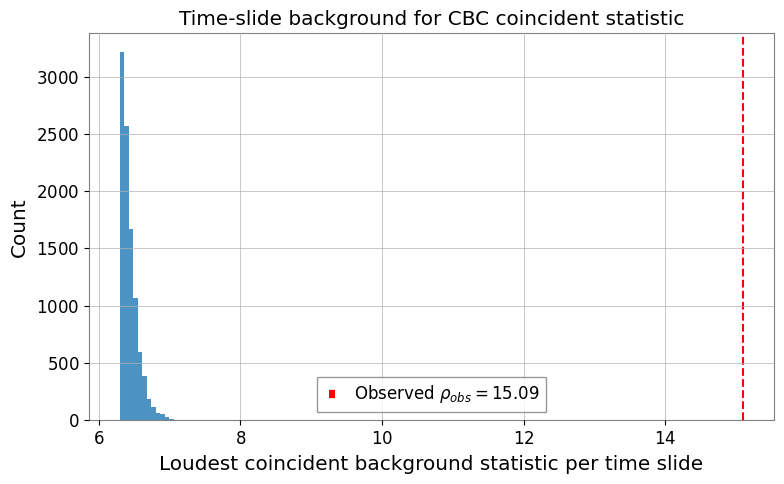

In [ ]:
# plotting the extended timeslide background to compare with the observed coincident statistic
plt.figure(figsize=(8,5))
plt.hist(bg_max_stats, bins=15, alpha=0.80)
plt.axvline(rho_obs, color="red", linestyle="--", label=fr"Observed $\rho_{{obs}}={rho_obs:.2f}$")
plt.xlabel("Loudest coincident background statistic per time slide")
plt.ylabel("Count")
plt.title("Time-slide background for CBC coincident statistic")
plt.legend()
#plt.xlim(14, 19)
plt.tight_layout()
plt.show()

The extended time-slide background shows a clear separation between the observed coincident statistic and the accidental background distribution. The observed value lies well to the right of the background histogram, and no slide in the finite background sample reaches it. This means that GW231123 is highly significant within this simplified coincident analysis.

In [ ]:
print("max offsource H1 =", np.max(rho_h1))
print("max offsource L1 =", np.max(rho_l1))

max offsource H1 = 6.303183234284451
max offsource L1 = 4.01146683829291


The largest off-source SNR excursions in the two detectors remain well below the observed coincident event statistic. This is noteworthy, since it suggests that the background does not contain unusually loud single-detector outliers. Instead, the significance is coming from the the two detectors at the event time.

In this section, I perform a reduced coherent parameter-estimation analysis for GW231123 using both the CBC and burst models. The purpose here is to see, in a simpler setup, how well each model can jointly describe the signal in the Hanford and Livingston detectors(Abac et al. 2025). To keep the analysis manageable, I keep the intrinsic waveform shape fixed and vary only a small set of timing, amplitude, and phase parameters that control the detector response. This gives a simpler but still useful comparison between the two signal descriptions.

### Part A

I first set up the short data segment and the frequency-domain series needed for the reduced coherent analysis. Since the likelihood is evaluated in the frequency domain, I take a short segment of data around the event, Fourier-transform it, and construct PSDs on the same frequency grid. I also define an initial reference time and detector delay guess, which will be used as starting points in the reduced fit.

I also define an initial reference time and detector delay guess, which will be used as starting points in the reduced fit.


In [ ]:
from scipy.optimize import minimize
from pycbc.psd import welch, interpolate

# Short data segment used for the reduced coherent analysis
pe_data = {
    ifo: search_data[ifo].time_slice(t0 - 0.40, t0 + 0.40)
    for ifo in ifos
}

# Frequency-domain data for the two detectors
dtilde = {
    ifo: pe_data[ifo].to_frequencyseries()
    for ifo in ifos
}

# Initial timing guesses from the CBC matched-filter peaks, if available
try:
    h1_peak_idx = np.argmax(np.abs(cbc_snr["H1"].numpy()))
    l1_peak_idx = np.argmax(np.abs(cbc_snr["L1"].numpy()))

    t_h1_peak = float(cbc_snr["H1"].sample_times[h1_peak_idx])
    t_l1_peak = float(cbc_snr["L1"].sample_times[l1_peak_idx])

    tau_h1_guess = t_h1_peak - t0              # H1 time offset relative to t0
    dt_hl_guess = t_l1_peak - t_h1_peak        # L1 - H1 delay
except Exception:
    tau_h1_guess = 0.0
    dt_hl_guess = 0.0

print(f"Initial tau_H1 guess = {tau_h1_guess:+.6f} s")
print(f"Initial dt_HL guess  = {dt_hl_guess:+.6f} s")

Initial tau_H1 guess = -0.088184 s
Initial dt_HL guess  = -0.002686 s


Here, I choose a short time window around the event and convert it into the frequency domain for both detectors. The PSDs are then estimated on the same frequency grid for consistency while estimating the likelihood. I also define a reference H1 trigger time and an initial Hanford–Livingston delay guess to initialise the fit.

In [ ]:
# PSDs on the same frequency grid as the PE data
psd_pe = {}
for ifo in ifos:
    psd = interpolate(welch(noise_data[ifo]), dtilde[ifo].delta_f)
    psd.resize(len(dtilde[ifo]))
    psd_pe[ifo] = psd

In [ ]:
# Build the reference CBC waveform on the same time grid as the PE segment

def wrap_phase(phi):
    return (phi + np.pi) % (2 * np.pi) - np.pi

# Time-domain CBC waveform using the same intrinsic parameters as earlier
delta_t_pe = float(pe_data["H1"].delta_t)
n_pe = len(pe_data["H1"])

hp_cbc_pe, hc_cbc_pe = get_td_waveform(
    approximant="IMRPhenomXPHM",
    mass1=m1_det,
    mass2=m2_det,
    spin1z=chi1,
    spin2z=chi2,
    distance=2000.0,
    inclination=np.pi / 2,
    delta_t=delta_t_pe,
    f_lower=20.0
)

h_raw = hp_cbc_pe.numpy()
peak_idx = np.argmax(np.abs(h_raw))

# Center the waveform so that its peak is placed at the middle of the PE segment
h_centered = np.zeros(n_pe)
center_idx = n_pe // 2

start = center_idx - peak_idx
i0 = max(0, start)
j0 = max(0, -start)
ncopy = min(len(h_raw) - j0, n_pe - i0)

h_centered[i0:i0 + ncopy] = h_raw[j0:j0 + ncopy]

# Rebuild as a PyCBC TimeSeries on the PE time grid
hp_cbc_centered = pycbctimeseries(
    h_centered,
    delta_t=delta_t_pe,
    epoch=float(pe_data["H1"].start_time)
)

# Convert to the frequency domain
h0_fd = hp_cbc_centered.to_frequencyseries()
h0_fd.resize(len(dtilde["H1"]))

freqs = h0_fd.sample_frequencies.numpy()
df = float(h0_fd.delta_f)
h0_np = h0_fd.numpy()

# Frequency range used in the reduced likelihood
fmask = (freqs >= 20.0) & (freqs <= 256.0)

# Noise-weighted inner product
def noise_weighted_inner_product(a, b, psd, mask):
    return 4.0 * np.real(np.sum(np.conjugate(a[mask]) * b[mask] / psd[mask]) * df)

# Normalize the reference waveform at the network level so that logA behaves more cleanly
cbc_norm2 = 0.0
for ifo in ifos:
    p = psd_pe[ifo].numpy()
    cbc_norm2 += noise_weighted_inner_product(h0_np, h0_np, p, fmask)

cbc_norm = np.sqrt(cbc_norm2)
h0_np = h0_np / cbc_norm

In the above cell, I generated the reference CBC waveform in the frequency domain using the same literature-motivated intrinsic parameters (mass, spin, etc.) used earlier. This waveform acts as the fixed shape for the reduced CBC parameter-estimation problem.
From now onwards in the report, the fitting does not change the intrinsic masses or spins, but only adjusts timing, amplitude, and phase parameters (Abac et al. 2025).




In [ ]:
# Reduced coherent CBC model, likelihood, prior, and posterior

cbc_bounds = np.array([
    [-0.02,  0.02],      # tau_h1 [s]
    [-0.02,  0.02],      # dt_hl  [s]
    [-8.0,   8.0],       # logA
    [-4.0,   4.0],       # logR
    [-np.pi, np.pi],     # phi [rad]
], dtype=float)

opt_bounds_cbc = [tuple(row) for row in cbc_bounds]

def build_cbc_network_model(x):
    """
    x = [tau_h1, dt_hl, logA, logR, phi]

    tau_h1 : H1 time offset relative to t0
    dt_hl  : L1 - H1 delay
    logA   : overall log amplitude
    logR   : relative log amplitude ratio between L1 and H1
    phi    : common phase
    """
    tau_h1, dt_hl, logA, logR, phi = map(float, x)
    phi = wrap_phase(phi)

    A_h1 = np.exp(logA)
    A_l1 = np.exp(logA + logR)

    phase_h1 = np.exp(-2j * np.pi * freqs * tau_h1 + 1j * phi)
    phase_l1 = np.exp(-2j * np.pi * freqs * (tau_h1 + dt_hl) + 1j * phi)

    h_h1 = A_h1 * h0_np * phase_h1
    h_l1 = A_l1 * h0_np * phase_l1

    return {"H1": h_h1, "L1": h_l1}

def log_likelihood_cbc(x):
    model = build_cbc_network_model(x)
    logl = 0.0

    for ifo in ifos:
        d = dtilde[ifo].numpy()
        p = psd_pe[ifo].numpy()
        h = model[ifo]

        resid = d - h
        logl += -0.5 * noise_weighted_inner_product(resid, resid, p, fmask)

    return logl
# Uniform prior
def log_prior_cbc(x):
    tau_h1, dt_hl, logA, logR, phi = map(float, x)
    phi = wrap_phase(phi)

    if not (cbc_bounds[0, 0] <= tau_h1 <= cbc_bounds[0, 1]):
        return -np.inf
    if not (cbc_bounds[1, 0] <= dt_hl <= cbc_bounds[1, 1]):
        return -np.inf
    if not (cbc_bounds[2, 0] <= logA <= cbc_bounds[2, 1]):
        return -np.inf
    if not (cbc_bounds[3, 0] <= logR <= cbc_bounds[3, 1]):
        return -np.inf
    if not (cbc_bounds[4, 0] <= phi <= cbc_bounds[4, 1]):
        return -np.inf

    return 0.0
#posterior  function
def log_posterior_cbc(x):
    lp = log_prior_cbc(x)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_cbc(x)

def neg_log_posterior_cbc(x):
    val = log_posterior_cbc(x)
    if not np.isfinite(val):
        return 1e100
    return -val

# Quick sanity check
x_test = np.array([tau_h1_guess, dt_hl_guess, 0.0, 0.0, 0.0])
print("Test log prior     =", log_prior_cbc(x_test))
print("Test log likelihood=", log_likelihood_cbc(x_test))
print("Test log posterior =", log_posterior_cbc(x_test))

Test log prior     = -inf
Test log likelihood= -423358215.2758144
Test log posterior = -inf


The reduced CBC model is built by applying the detector-response parameters to the fixed reference waveform. The free parameters are the H1 time offset, the H1–L1 delay, an overall amplitude scale, a relative amplitude ratio between the detectors, and a common phase.
This is a simplified, coherent model that fits the two detector singals jointly using a single common signal description, rather than fitting them independently.

The likelihood is written in the standard Gaussian form in the frequency domain, where the residual between the data and the model is weighted by the detector PSD. This means the fit naturally downweights noisy frequency bins and gives more weight to frequency ranges where the detectors are more sensitive. I then combine this likelihood with simple box priors to define the reduced posterior, which is used both for maximisation and later for sampling.

### Part B

I now maximise the reduced CBC posterior to find the best-fit point in this simplified 5D parameter space. Since the posterior surface can contain local maxima, I start the optimisation from several different initial guesses rather than relying on a single starting point. I then use the best-fit solution as a reference for profile scans of the likelihood and posterior.

In [ ]:
# defining multiple starting points for the parameters
# Optimization of the reduced CBC posterior

x0_list = [
    np.array([tau_h1_guess, dt_hl_guess,  0.0,  0.0, 0.0]),
    np.array([tau_h1_guess, dt_hl_guess, -0.5,  0.0, 0.0]),
    np.array([tau_h1_guess, dt_hl_guess,  0.5,  0.0, np.pi / 2]),
    np.array([tau_h1_guess + 0.002, 0.0,  0.0,  0.0, -np.pi / 2]),
]



In above cell, I define the prior bounds and a small set of different starting points for the optimiser.

In [ ]:
results = []
for x0 in x0_list:
    res = minimize(
        neg_log_posterior_cbc,
        x0,
        method="L-BFGS-B",
        bounds=opt_bounds_cbc
    )
    results.append(res)

best_res = min(results, key=lambda r: r.fun)
x_best = best_res.x.copy()
x_best[4] = wrap_phase(x_best[4])

print("Best-fit CBC parameters:")
print(f"tau_h1 = {x_best[0]:+.6f} s")
print(f"dt_hl  = {x_best[1]:+.6f} s")
print(f"logA   = {x_best[2]:+.4f}")
print(f"logR   = {x_best[3]:+.4f}")
print(f"phi    = {x_best[4]:+.4f} rad")
print()
print(f"Best-fit H1 GPS time = {t0 + x_best[0]:.6f}")
print(f"Maximum log posterior = {-best_res.fun:.6e}")

Best-fit CBC parameters:
tau_h1 = -0.008619 s
dt_hl  = -0.010246 s
logA   = +3.8682
logR   = +2.0560
phi    = +1.6148 rad

Best-fit H1 GPS time = 1384782888.691381
Maximum log posterior = -4.233263e+08


The optimisation returns a best-fit point for the reduced CBC model. However, some of the fitted parameters lie close to prior boundaries, especially the phase and some of the amplitude-related terms. This suggests that the reduced model may be compensating for its simplifications by pushing nuisance parameters toward extreme values. For that reason, I treat this best-fit point mainly as a reference point for exploring the local posterior structure. This is consistent with the fact that GW231123 lies in a regime where waveform modelling is known to be difficult and can lead to non-negligible systematic differences in inference (Abac et al. 2025).

To better understand the behaviour of the reduced CBC fit, I next scan the likelihood and posterior around the best-fit point by varying one parameter at a time while keeping the other four fixed. This gives a local profile view of how sharply each parameter is constrained in the neighbourhood of the optimum value.

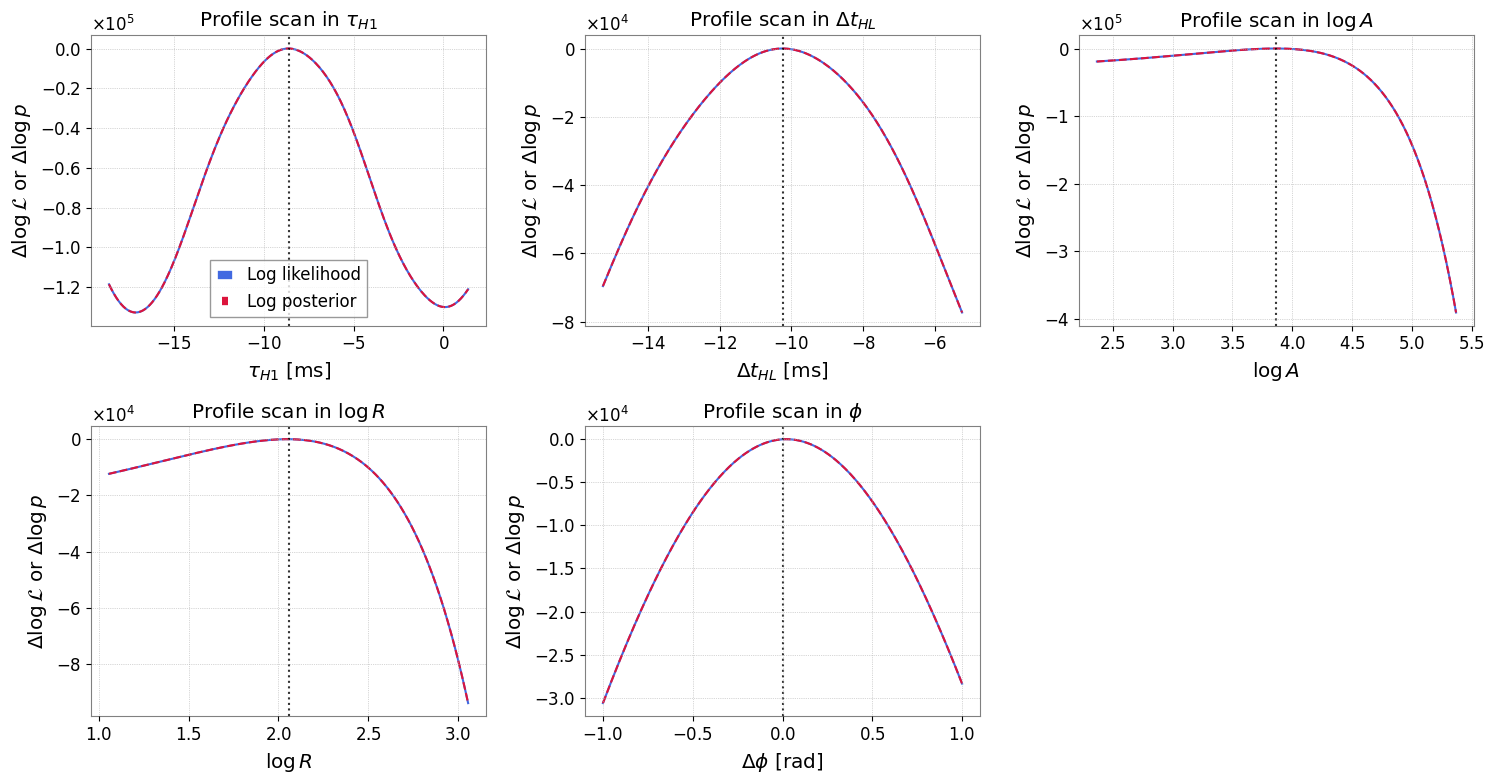

In [ ]:
# Profile scans of the likelihood and posterior around the best-fit point

param_names = [r"$\tau_{H1}$", r"$\Delta t_{HL}$", r"$\log A$", r"$\log R$", r"$\phi$"]
param_units = ["ms", "ms", "", "", "rad"]

scan_halfwidths = [
    0.010,   # tau_h1 [s]
    0.005,   # dt_hl [s]
    1.5,     # logA
    1.0,     # logR
    1.0      # phi [rad]
]

npts = 300

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i in range(5):
    x0 = x_best[i]
    hw = scan_halfwidths[i]

    if i == 4:
        delta_grid = np.linspace(-hw, hw, npts)
        xgrid_display = delta_grid
        xgrid_eval = wrap_phase(x0 + delta_grid)
        xlabel = r"$\Delta \phi$ [rad]"
        xline = 0.0
    else:
        xgrid_eval = np.linspace(x0 - hw, x0 + hw, npts)
        xgrid_display = xgrid_eval.copy()

        if i in [0, 1]:
            xgrid_display = 1e3 * xgrid_display
            xline = 1e3 * x0
            xlabel = f"{param_names[i]} [{param_units[i]}]"
        else:
            xline = x0
            xlabel = param_names[i] if param_units[i] == "" else f"{param_names[i]} [{param_units[i]}]"

    logL_vals = []
    logpost_vals = []

    for val in xgrid_eval:
        x = x_best.copy()
        x[i] = val
        logL_vals.append(log_likelihood_cbc(x))
        logpost_vals.append(log_posterior_cbc(x))

    logL_vals = np.array(logL_vals)
    logpost_vals = np.array(logpost_vals)

    ax = axes[i]
    ax.plot(xgrid_display, logL_vals - np.max(logL_vals), color="royalblue", lw=1.5, label="Log likelihood")
    ax.plot(xgrid_display, logpost_vals - np.max(logpost_vals), color="crimson", lw=1.5, ls="--", label="Log posterior")
    ax.axvline(xline, color="black", linestyle=":", alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\Delta \log \mathcal{L}$ or $\Delta \log p$")
    ax.set_title(f"Profile scan in {param_names[i]}")
    ax.grid(True, ls=":")

    if i == 0:
        ax.legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In principle, narrower and more symmetric peaks indicate better local identifiability, while flatter, skewed, or edge-limited behaviour suggests that the parameter is either weakly constrained or partly absorbing model mismatch. In the present CBC fit shown above, the timing parameters are easier to interpret than the amplitude-related parameters.

### Part C

I next sample the full reduced CBC posterior using MCMC. The reason for switching to sampling at this stage is that a single best-fit point does not tell us about parameter uncertainty, degeneracies, or whether the posterior is concentrated in a single region or spread across several regions. MCMC is therefore used here to map out the local posterior structure in the chosen reduced parameter space.

In [ ]:
!pip install emcee

I use the `emcee` ensemble sampler here because it interfaces directly with the posterior function already defined above and is well suited to exploring a moderately sized reduced parameter space like this one.

In the following code cells, I initialise an ensemble of walkers near the best-fit point and retain only walkers with finite posterior values. This is mainly a numerical precaution; if the walkers are initialised too widely, some can begin in regions where the posterior is undefined or essentially zero, which only makes the sampling messier. The phase is also wrapped into a periodic interval so that the sampler does not get confused by the artificial discontinuity between 0 and $2\pi$.

In [ ]:
import emcee
import numpy as np
import matplotlib.pyplot as plt

x_best_mcmc = x_best.copy()
x_best_mcmc[4] = wrap_phase(x_best_mcmc[4])

ndim = 5
nwalkers = 40

scale = np.array([
    2e-4,   # tau_h1
    2e-4,   # dt_hl
    0.05,   # logA
    0.05,   # logR
    0.05    # phi
])

rng = np.random.default_rng(42)

p0_list = []
while len(p0_list) < nwalkers:
    trial = x_best_mcmc + scale * rng.normal(size=ndim)

    trial[4] = wrap_phase(trial[4])
    for i in range(4):
        lo, hi = cbc_bounds[i]
        trial[i] = np.clip(trial[i], lo + 1e-8, hi - 1e-8)

    if np.isfinite(log_posterior_cbc(trial)):
        p0_list.append(trial)

p0 = np.array(p0_list)

lp0 = np.array([log_posterior_cbc(pos) for pos in p0])
print("Finite initial walkers:", np.sum(np.isfinite(lp0)), "/", len(lp0))
print("Initial log-posterior range:", np.nanmin(lp0), np.nanmax(lp0))

sampler_cbc = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior_cbc
)

Finite initial walkers: 40 / 40
Initial log-posterior range: -423328197.6645598 -423326286.1509547


### Part D

In [ ]:
n_burn = 3000
state = sampler_cbc.run_mcmc(p0, n_burn, progress=True)

sampler_cbc.reset()

n_prod = 8000
sampler_cbc.run_mcmc(state, n_prod, progress=True)

100%|██████████| 8000/8000 [01:32<00:00, 86.07it/s]


State([[ 3.53628853e-04 -1.43881930e-02  4.67597277e+00
   1.34941383e+00  3.33805826e+00]
 [ 3.39661429e-04 -1.43371964e-02  4.64975004e+00
   1.37454349e+00  3.34556406e+00]
 [ 3.38444949e-04 -1.43428573e-02  4.67834782e+00
   1.34478527e+00  3.34563269e+00]
 [ 3.74845496e-04 -1.43712438e-02  4.66928562e+00
   1.35802639e+00  3.34731896e+00]
 [ 3.77871064e-04 -1.43840969e-02  4.66358512e+00
   1.36898132e+00  3.34678365e+00]
 [ 3.43641434e-04 -1.43350787e-02  4.68848755e+00
   1.34497894e+00  3.34870130e+00]
 [ 3.33391701e-04 -1.43696619e-02  4.67389670e+00
   1.35650072e+00  3.33814794e+00]
 [ 3.81127711e-04 -1.43538045e-02  4.66500089e+00
   1.37031030e+00  3.36110152e+00]
 [ 4.01804757e-04 -1.43596783e-02  4.67804986e+00
   1.35958832e+00  3.36604032e+00]
 [ 3.66890699e-04 -1.43738405e-02  4.68463440e+00
   1.34347731e+00  3.33709726e+00]
 [ 3.37252701e-04 -1.43453598e-02  4.68147215e+00
   1.34961154e+00  3.34310008e+00]
 [ 3.91910824e-04 -1.43813218e-02  4.65081140e+00
   1.3754

The MCMC is run in two stages: a burn-in phase, which allows the walkers to settle into the dominant posterior region, and a production phase, from which the actual posterior samples are taken. This is standard practice in MCMC-based inference, since the initial part of the chain is often still influenced by walkers' arbitrary starting positions.

In [ ]:
accept_frac = np.mean(sampler_cbc.acceptance_fraction)

print(f"Mean acceptance fraction = {accept_frac:.3f}")
print(f"Chain shape = {sampler_cbc.get_chain().shape}")   # (nsteps, nwalkers, ndim)

Mean acceptance fraction = 0.544
Chain shape = (8000, 40, 5)


The mean acceptance fraction gives us a quick indication of whether the sampler is moving sensibly through parameter space or not. In this run, the acceptance fraction is numerically reasonable, so the sampler itself is not obviously failing. However, good numerical sampling does not automatically mean that the resulting posterior is physically trustworthy; that still depends on the reduced model being a sensible description of the signal.

In [ ]:
# Basic sampler outputs

accept_frac = np.mean(sampler_cbc.acceptance_fraction)

print(f"Mean acceptance fraction = {accept_frac:.3f}")
print(f"Chain shape = {sampler_cbc.get_chain().shape}")

chain_cbc = sampler_cbc.get_chain()
flat_samples_cbc = sampler_cbc.get_chain(flat=True)

print("Flat sample shape:", flat_samples_cbc.shape)

# Wrap the phase samples for summaries and plots
chain_cbc_wrapped = chain_cbc.copy()
chain_cbc_wrapped[:, :, 4] = wrap_phase(chain_cbc_wrapped[:, :, 4])

flat_samples_cbc_wrapped = flat_samples_cbc.copy()
flat_samples_cbc_wrapped[:, 4] = wrap_phase(flat_samples_cbc_wrapped[:, 4])

Mean acceptance fraction = 0.544
Chain shape = (8000, 40, 5)
Flat sample shape: (320000, 5)


In [ ]:
# Walker diagnostics

logp_chain = sampler_cbc.get_log_prob()
walker_med_logp = np.median(logp_chain, axis=0)

print("Median log posterior per walker:")
print(walker_med_logp)

finite_walker_mask = np.isfinite(walker_med_logp)
threshold = np.nanmax(walker_med_logp[finite_walker_mask]) - 50.0
good_walkers = finite_walker_mask & (walker_med_logp > threshold)

print("Good walkers:", np.where(good_walkers)[0])
print("Bad walkers :", np.where(~good_walkers)[0])

Median log posterior per walker:
[-4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316149e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08
 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08 -4.23316148e+08]
Good walkers: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20
 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Bad walkers : []


I also check the walkers individually to see whether some are exploring clearly worse regions of the posterior than the others. This is a diagnostic step to identify walkers that are badly initialised or poorly mixing before looking at the trace plots. In the current CBC run, the walkers cluster very tightly in a single region, suggesting that the reduced posterior is extremely narrow in this parameterisation.

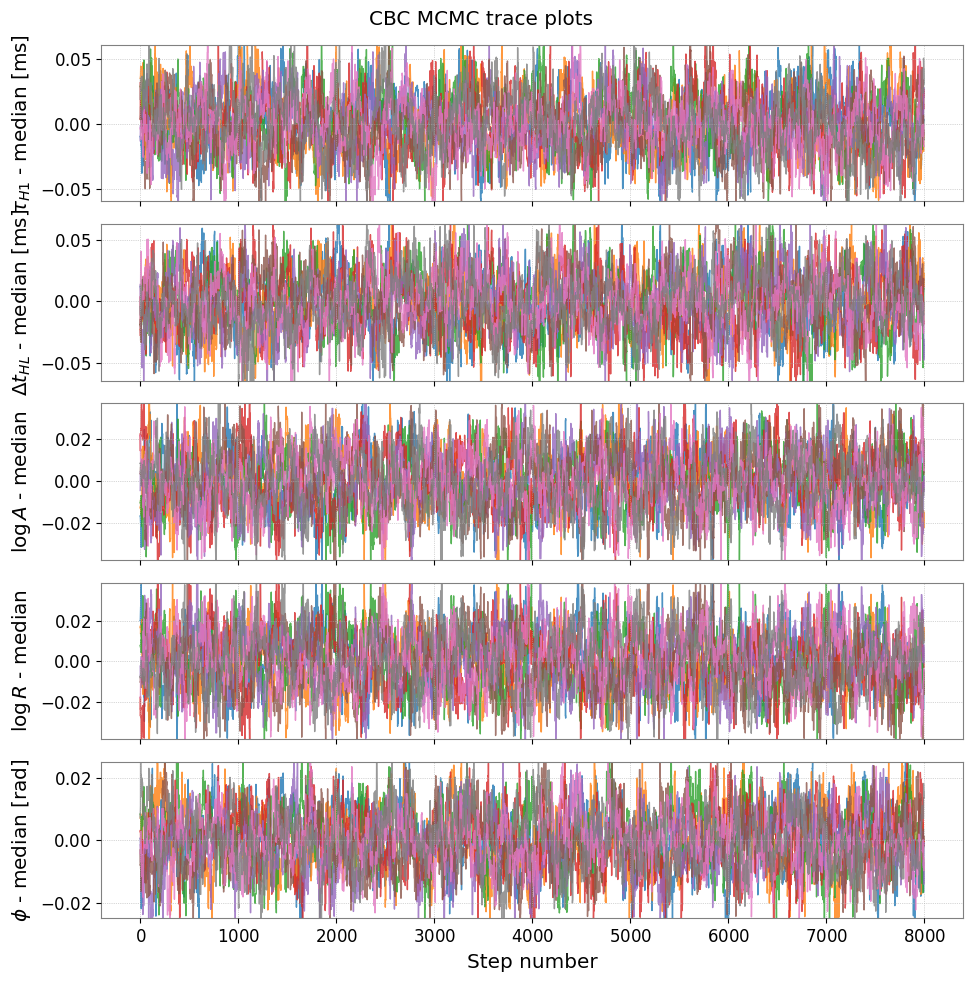

In [ ]:
# Trace plots for a subset of well-behaved walkers

labels_5d = [r"$\tau_{H1}$", r"$\Delta t_{HL}$", r"$\log A$", r"$\log R$", r"$\phi$"]
units_5d = ["ms", "ms", "", "", "rad"]
plot_scales = np.array([1e3, 1e3, 1.0, 1.0, 1.0])

medians_cbc = np.median(flat_samples_cbc_wrapped, axis=0)

good_ids = np.where(good_walkers)[0][:8]
if len(good_ids) == 0:
    good_ids = np.where(finite_walker_mask)[0][:8]

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i in range(5):
    y_all = []

    for w in good_ids:
        y = plot_scales[i] * (chain_cbc_wrapped[:, w, i] - medians_cbc[i])
        y_all.append(y)
        axes[i].plot(y, lw=1.0, alpha=0.8)

    y_all = np.concatenate(y_all)
    lo, hi = np.percentile(y_all[np.isfinite(y_all)], [2, 98])
    pad = 0.2 * (hi - lo + 1e-12)
    axes[i].set_ylim(lo - pad, hi + pad)

    ylabel = labels_5d[i]
    if units_5d[i]:
        ylabel += f" - median [{units_5d[i]}]"
    else:
        ylabel += " - median"

    axes[i].set_ylabel(ylabel)
    axes[i].grid(True, ls=":")

axes[-1].set_xlabel("Step number")
fig.suptitle("CBC MCMC trace plots")
plt.tight_layout()
plt.show()

The trace plot shows that the walkers remain concentrated in a very narrow region of parameter space once the burn-in has finished. In a way this is reassuring, since there is no obvious sign of the chains drifting away or splitting into multiple separated modes. At the same time, the extremely small spread of the chains is a warning that the reduced model is likely underestimating the true uncertainty by conditioning on a fixed waveform shape and a simplified detector-response parameterization.

In [ ]:
# Posterior summaries

def circular_summary(samples):
    samples = wrap_phase(np.asarray(samples))
    center = np.angle(np.mean(np.exp(1j * samples)))
    shifted = wrap_phase(samples - center)
    q_shifted = np.percentile(shifted, [16, 50, 84])
    q = wrap_phase(center + q_shifted)
    return q

tau_samples  = flat_samples_cbc_wrapped[:, 0]
dt_samples   = flat_samples_cbc_wrapped[:, 1]
logA_samples = flat_samples_cbc_wrapped[:, 2]
logR_samples = flat_samples_cbc_wrapped[:, 3]
phi_samples  = flat_samples_cbc_wrapped[:, 4]

tau_q  = np.percentile(tau_samples,  [16, 50, 84])
dt_q   = np.percentile(dt_samples,   [16, 50, 84])
logA_q = np.percentile(logA_samples, [16, 50, 84])
logR_q = np.percentile(logR_samples, [16, 50, 84])
phi_q  = circular_summary(phi_samples)

print("tau_H1 [s]:")
print(f"  median = {tau_q[1]:+.6f}")
print(f"  16-84% = [{tau_q[0]:+.6f}, {tau_q[2]:+.6f}]")

print("\ndt_HL [s]:")
print(f"  median = {dt_q[1]:+.6f}")
print(f"  16-84% = [{dt_q[0]:+.6f}, {dt_q[2]:+.6f}]")

print("\nlogA:")
print(f"  median = {logA_q[1]:+.4f}")
print(f"  16-84% = [{logA_q[0]:+.4f}, {logA_q[2]:+.4f}]")

print("\nlogR:")
print(f"  median = {logR_q[1]:+.4f}")
print(f"  16-84% = [{logR_q[0]:+.4f}, {logR_q[2]:+.4f}]")

print("\nphi [rad]:")
print(f"  median = {phi_q[1]:+.4f}")
print(f"  16-84% = [{phi_q[0]:+.4f}, {phi_q[2]:+.4f}]")

tau_H1 [s]:
  median = +0.000350
  16-84% = [+0.000329, +0.000372]

dt_HL [s]:
  median = -0.014353
  16-84% = [-0.014375, -0.014331]

logA:
  median = +4.6687
  16-84% = [+4.6559, +4.6812]

logR:
  median = +1.3609
  16-84% = [+1.3479, +1.3742]

phi [rad]:
  median = -2.9356
  16-84% = [-2.9444, -2.9269]


The posterior medians and credible intervals for the reduced CBC parameters are extremely narrow, and several parameters remain effectively stuck at prior boundaries. This means that the sampler is not revealing a broad physical uncertainty region, but rather a highly restricted local mode of the simplified model. In particular, the very small posterior widths here should not be interpreted as realistic astrophysical uncertainties. They only reflect uncertainty within the reduced, heavily conditioned parameterisation used in this notebook.

In [ ]:
!pip install corner

To visualise the pairwise structure of the reduced CBC posterior more clearly, I now plot the posterior samples using a corner plot. This helps show whether the parameters are tightly clustered, correlated, or affected by narrow degeneracy directions.

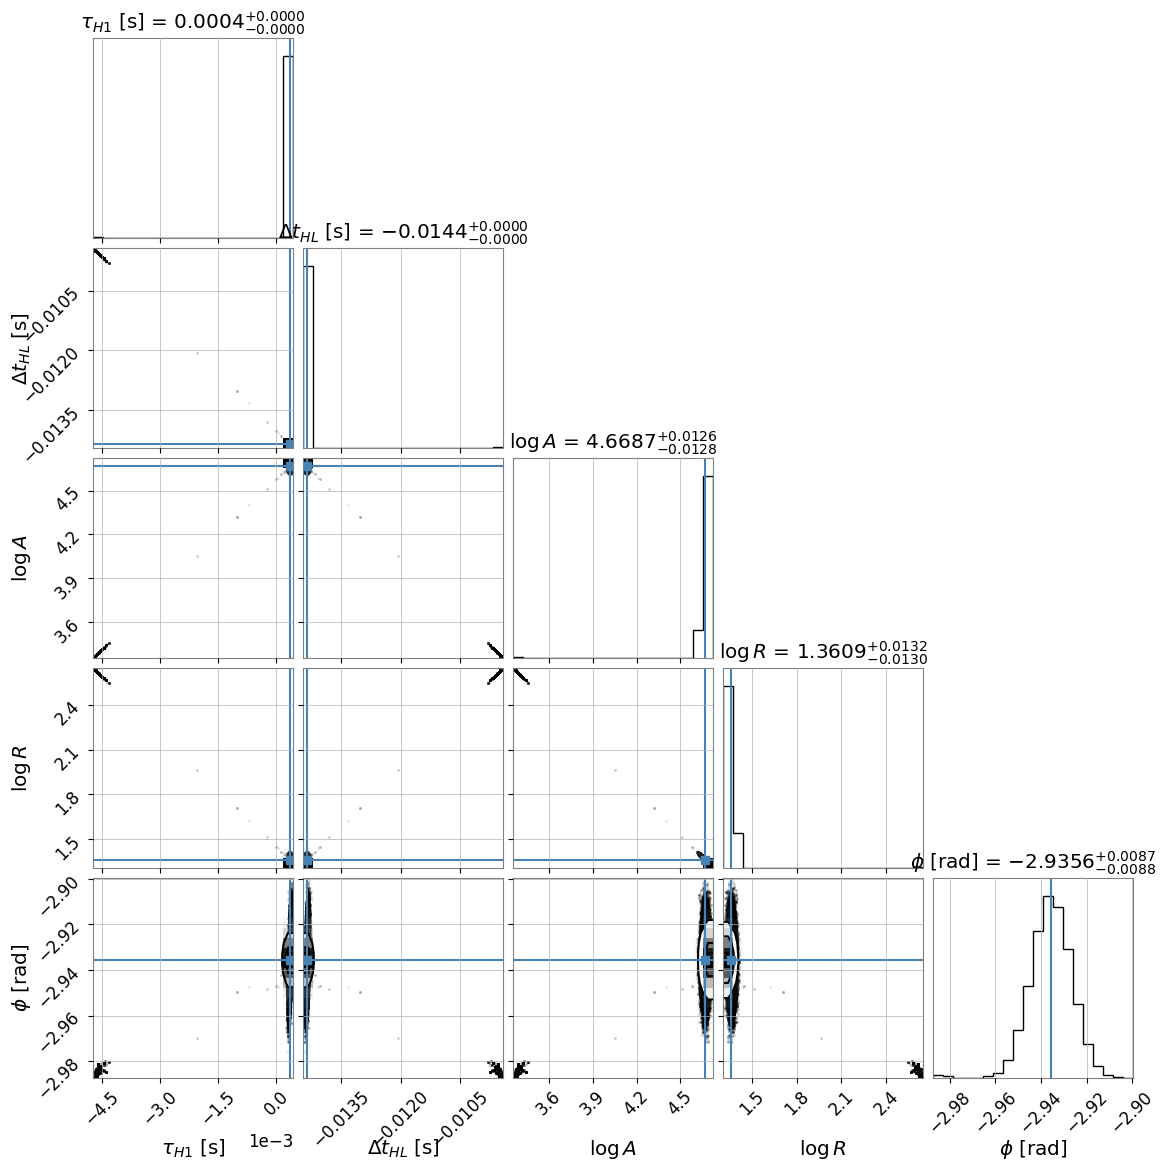

In [ ]:
# Corner plot and timing-posterior plot

fig = corner.corner(
    flat_samples_cbc_wrapped,
    labels=[
        r"$\tau_{H1}$ [s]",
        r"$\Delta t_{HL}$ [s]",
        r"$\log A$",
        r"$\log R$",
        r"$\phi$ [rad]"
    ],
    truths=[
        tau_q[1],
        dt_q[1],
        logA_q[1],
        logR_q[1],
        phi_q[1]
    ],
    show_titles=True,
    title_fmt=".4f"
)
plt.show()


The corner plot makes this behaviour clearer: the posterior is highly concentrated and shows very little spread in the reduced 5D space. While this confirms that the sampler has identified a dominant mode, it also reinforces the point that the current CBC-reduced model is too restrictive to be interpreted as a full physical-parameter-estimation result(Abac et al. 2025). The most useful information from this fit comes from the model's ability to localise a coherent timing solution, not from the apparent precision of the nuisance parameters.

### Part E

I now repeat the reduced coherent analysis using the phenomenological burst model instead of the CBC waveform. The main difference is that the burst model does not describe the astrophysical binary directly, but instead describes the shape of a short transient signal. I therefore use it here as a comparison model, keeping the setup as parallel as possible to the CBC case while allowing the burst fit to adjust its own timing, amplitude, and phase.


In [ ]:
# Burst template parameters from earlier morphology matching

f0_burst_pe = 60.0
Q_burst_pe = 8.0
hrss_burst_pe = 1e-21

delta_t_pe = float(pe_data["H1"].delta_t)
n_pe = len(pe_data["H1"])

# Build burst in time domain on the same PE sampling grid
hp_burst_pe, hc_burst_pe = get_sgburst_waveform(
    approximant="SineGaussian",
    q=Q_burst_pe,
    frequency=f0_burst_pe,
    hrss=hrss_burst_pe,
    delta_t=delta_t_pe,
    polarization=0
)

h_raw = hp_burst_pe.numpy()
peak_idx = np.argmax(np.abs(h_raw))

# Center the burst in an array of the same length as the PE data
h_centered = np.zeros(n_pe)
center_idx = n_pe // 2

start = center_idx - peak_idx
i0 = max(0, start)
j0 = max(0, -start)
ncopy = min(len(h_raw) - j0, n_pe - i0)

h_centered[i0:i0+ncopy] = h_raw[j0:j0+ncopy]

# Rebuild as a PyCBC TimeSeries on the PE grid
hp_burst_centered = pycbctimeseries(
    h_centered,
    delta_t=delta_t_pe,
    epoch=pe_data["H1"].start_time
)

# Convert to frequency domain
h0_burst_fd = hp_burst_centered.to_frequencyseries()
h0_burst_fd.resize(len(dtilde["H1"]))

h0_burst_np = h0_burst_fd.numpy()

# Optional network normalization so logA stays more interpretable
burst_norm2 = 0.0
for ifo in ifos:
    p = psd_pe[ifo].numpy()
    burst_norm2 += noise_weighted_inner_product(h0_burst_np, h0_burst_np, p, fmask)

burst_norm = np.sqrt(burst_norm2)
h0_burst_np = h0_burst_np / burst_norm

In this cell, I construct the reference burst waveform on the same parameter-estimation grid used for the data. The burst is centred in the analysis window and then transformed into the frequency domain so that it can be used in exactly the same likelihood framework as the CBC model. I also normalise the burst template with the network inner product, which helps keep the amplitude scaling better behaved in the reduced fit.

In [ ]:
def wrap_phase(phi):
    return (phi + np.pi) % (2 * np.pi) - np.pi

# Burst reduced parameter vector:
# x = [tau_h1, dt_hl, logA, phi]

burst_bounds = np.array([
    [-0.02,  0.02],      # tau_h1 [s]
    [-0.02,  0.02],      # dt_hl  [s]
    [-8.0,   8.0],       # logA
    [-np.pi, np.pi],     # phi [rad]
], dtype=float)


def build_burst_network_model(x):
    """
    x = [tau_h1, dt_hl, logA, phi]
    """
    tau_h1, dt_hl, logA, phi = map(float, x)

    A = np.exp(logA)
    phi = wrap_phase(phi)

    phase_h1 = np.exp(-2j * np.pi * freqs * tau_h1 + 1j * phi)
    phase_l1 = np.exp(-2j * np.pi * freqs * (tau_h1 + dt_hl) + 1j * phi)

    h_h1 = A * h0_burst_np * phase_h1
    h_l1 = A * h0_burst_np * phase_l1

    return {"H1": h_h1, "L1": h_l1}


def log_likelihood_burst(x):
    model = build_burst_network_model(x)
    logl = 0.0

    for ifo in ifos:
        d = dtilde[ifo].numpy()
        p = psd_pe[ifo].numpy()
        h = model[ifo]

        resid = d - h
        logl += -0.5 * noise_weighted_inner_product(resid, resid, p, fmask)

    return logl


def log_prior_burst(x):
    tau_h1, dt_hl, logA, phi = x
    phi = wrap_phase(phi)

    if not (-0.02 <= tau_h1 <= 0.02):
        return -np.inf

    if not (-0.02 <= dt_hl <= 0.02):
        return -np.inf

    if not (-8.0 <= logA <= 8.0):
        return -np.inf

    if not (-np.pi <= phi <= np.pi):
        return -np.inf

    return 0.0


def log_posterior_burst(x):
    lp = log_prior_burst(x)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_burst(x)


def neg_log_posterior_burst(x):
    val = log_posterior_burst(x)
    if not np.isfinite(val):
        return 1e100
    return -val

The burst posterior is defined in the same way as the CBC posterior, but with a smaller parameter set: an H1 time offset, an H1–L1 delay, an overall amplitude scale, and a common phase. I do not include a separate detector-amplitude-ratio parameter here, since that would make the burst fit even more flexible and harder to interpret. The burst model is therefore simpler, but still coherent in the sense that it is fitted jointly to both detectors.

In [ ]:
from scipy.optimize import minimize

# Bounds for the reduced burst parameter-estimation problem
bounds_burst = [
    (-0.02, 0.02),     # tau_h1: H1 time offset [s]
    (-0.02, 0.02),     # dt_hl: H1-L1 delay [s]
    (-8.0, 8.0),       # logA: overall log amplitude
    (-np.pi, np.pi)    # phi: common phase [rad]
]

# A small set of different starting points for the optimiser
x0_list_burst = [
    np.array([0.0, dt_hl_guess,  0.0,  0.0]),
    np.array([0.0, dt_hl_guess, -0.5,  0.0]),
    np.array([0.0, dt_hl_guess,  0.5,  np.pi/2]),
    np.array([0.002, 0.0,        0.0, -np.pi/2]),
]

# Run the optimisation from each initial guess
results_burst = []
for x0 in x0_list_burst:
    res = minimize(
        neg_log_posterior_burst,
        x0,
        method="L-BFGS-B",
        bounds=bounds_burst
    )
    results_burst.append(res)

# Keep the solution with the highest posterior
best_res_burst = min(results_burst, key=lambda r: r.fun)
x_best_burst = best_res_burst.x

# Wrap the phase back into the chosen interval [-pi, pi]
x_best_burst[3] = wrap_phase(x_best_burst[3])

# Print the best-fit burst parameters
print("Best-fit burst parameters:")
print(f"tau_h1 = {x_best_burst[0]:+.6f} s")
print(f"dt_hl  = {x_best_burst[1]:+.6f} s")
print(f"logA   = {x_best_burst[2]:+.4f}")
print(f"phi    = {x_best_burst[3]:+.4f} rad")
print()
print(f"Maximum burst log posterior = {-best_res_burst.fun:.6e}")

Best-fit burst parameters:
tau_h1 = -0.016524 s
dt_hl  = -0.007139 s
logA   = +5.8867
phi    = +1.8968 rad

Maximum burst log posterior = -4.232944e+08


The burst optimisation returns a stable best-fit point in the reduced burst-parameter space. Compared to the CBC case, this fit is numerically cleaner and does not show the same obvious tendency to pin multiple parameters to hard prior limits. However, the fitted burst amplitude remains very large, which suggests that the amplitude parameter is still acting more like a nuisance compensation parameter than a directly physical quantity.

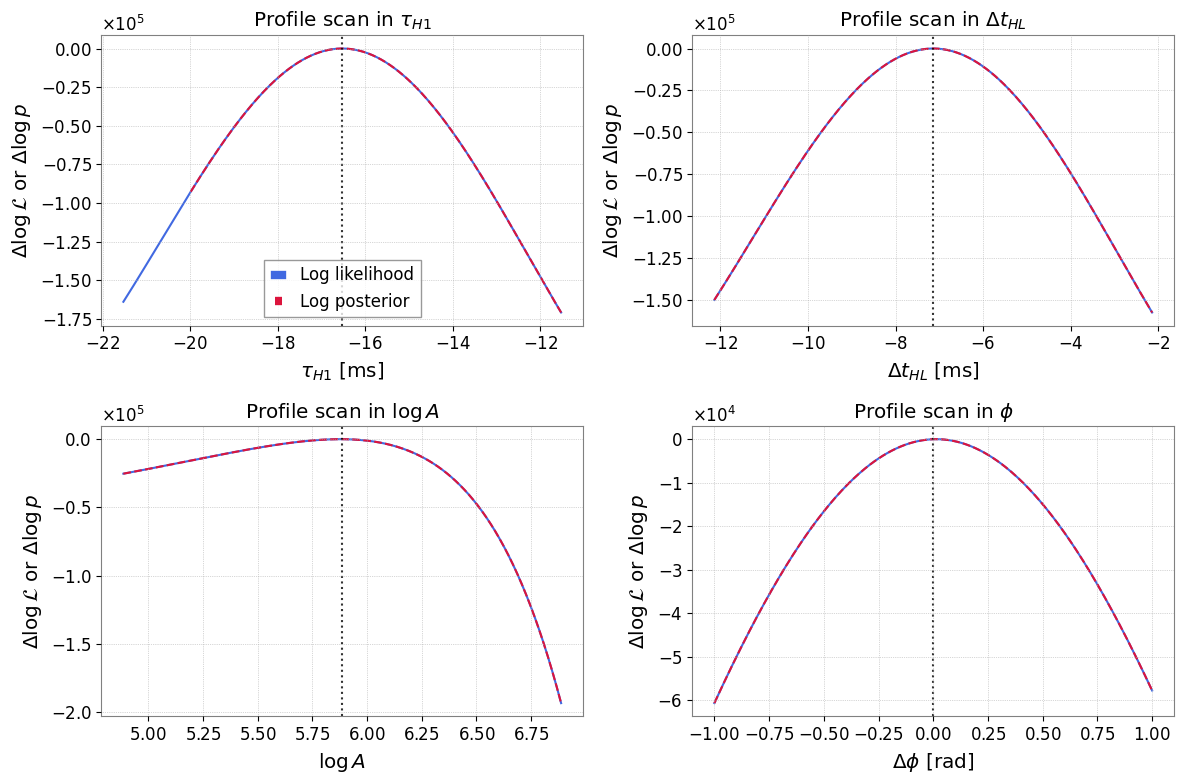

In [ ]:
# Parameter labels and plotting units for the burst model
param_names_burst = [r"$\tau_{H1}$", r"$\Delta t_{HL}$", r"$\log A$", r"$\phi$"]
param_units_burst = ["ms", "ms", "", "rad"]

# Half-width of the 1D scan around the best-fit value for each parameter
scan_halfwidths_burst = [
    0.005,   # tau_h1 [s]
    0.005,   # dt_hl [s]
    1.0,     # logA
    1.0      # phi [rad]
]

npts = 300  # number of points used in each 1D scan

# Set up a 2x2 panel figure, one subplot for each burst parameter
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i in range(4):
    # Best-fit value and scan width for the current parameter
    x0 = x_best_burst[i]
    hw = scan_halfwidths_burst[i]

    # For phase, scan relative to the best-fit value and wrap periodically
    if i == 3:
        delta_grid = np.linspace(-hw, hw, npts)
        xgrid_display = delta_grid
        xgrid_eval = wrap_phase(x0 + delta_grid)
        xlabel = r"$\Delta \phi$ [rad]"
        xline = 0.0

    # For all other parameters, scan directly around the best-fit value
    else:
        xgrid_eval = np.linspace(x0 - hw, x0 + hw, npts)
        xgrid_display = xgrid_eval.copy()

        # Convert timing parameters to ms for plotting
        if i in [0, 1]:
            xgrid_display = 1e3 * xgrid_display
            xline = 1e3 * x0
            xlabel = f"{param_names_burst[i]} [{param_units_burst[i]}]"
        else:
            xline = x0
            xlabel = param_names_burst[i]

    logL_vals = []
    logpost_vals = []

    # Evaluate the likelihood and posterior while varying only one parameter and keeping the others fixed

    for val in xgrid_eval:
        x = x_best_burst.copy()
        x[i] = val
        logL_vals.append(log_likelihood_burst(x))
        logpost_vals.append(log_posterior_burst(x))

    logL_vals = np.array(logL_vals)
    logpost_vals = np.array(logpost_vals)

    # Plot each curve relative to its own maximum for easier comparison
    ax = axes[i]
    ax.plot(
        xgrid_display,
        logL_vals - np.max(logL_vals),
        color="royalblue",
        lw=1.5,
        label="Log likelihood"
    )
    ax.plot(
        xgrid_display,
        logpost_vals - np.max(logpost_vals),
        color="crimson",
        lw=1.5,
        ls="--",
        label="Log posterior"
    )
    ax.axvline(xline, color="black", linestyle=":", alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\Delta \log \mathcal{L}$ or $\Delta \log p$")
    ax.set_title(f"Profile scan in {param_names_burst[i]}")
    ax.grid(True, ls=":")

    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

I again examine the local shape of the burst posterior by scanning one parameter at a time around the best-fit point. This helps check whether the fit is sharply localised in timing and phase, and whether any parameters are still strongly skewed or prior-sensitive. In the burst case, the behaviour is generally cleaner than in the CBC fit, although the amplitude scale remains difficult to interpret physically.

Finally, I sample the reduced-burst posterior using MCMC.

In [ ]:
# Start the burst walkers near the optimiser solution
# Wrap the phase so that it is represented in a continuous interval
x_best_burst_mcmc = x_best_burst.copy()
x_best_burst_mcmc[3] = wrap_phase(x_best_burst_mcmc[3])

ndim_burst = 4
nwalkers_burst = 36

# initial spread around the best-fit burst parameters
scale_burst = np.array([
    2e-4,   # tau_h1
    2e-4,   # dt_hl
    0.05,   # logA
    0.05    # phi
])

rng = np.random.default_rng(123)

# Build an initial ensemble of burst walkers, keeping only finite-posterior points
p0_list_burst = []
while len(p0_list_burst) < nwalkers_burst:
    trial = x_best_burst_mcmc + scale_burst * rng.normal(size=ndim_burst)

    # Wrap phase into the chosen periodic interval
    trial[3] = wrap_phase(trial[3])

    # Keep the non-phase parameters safely the allowed bounds
    for i in range(3):
        lo, hi = burst_bounds[i]
        trial[i] = np.clip(trial[i], lo + 1e-8, hi - 1e-8)

    # Only retain walkers that start in a valid posterior region
    if np.isfinite(log_posterior_burst(trial)):
        p0_list_burst.append(trial)

p0_burst = np.array(p0_list_burst)

# Check that all initial walkers are valid
lp0_burst = np.array([log_posterior_burst(pos) for pos in p0_burst])
print("Finite initial burst walkers:", np.sum(np.isfinite(lp0_burst)), "/", len(lp0_burst))
print("Initial burst log-posterior range:", np.nanmin(lp0_burst), np.nanmax(lp0_burst))

# Set up the ensemble sampler for the burst posterior
sampler_burst = emcee.EnsembleSampler(
    nwalkers_burst,
    ndim_burst,
    log_posterior_burst
)

Finite initial burst walkers: 36 / 36
Initial burst log-posterior range: -423299946.2285137 -423294367.61457884


In [ ]:
# Run the burst MCMC chain for an initial burn-in phase
n_burn_burst = 3000
state_burst = sampler_burst.run_mcmc(p0_burst, n_burn_burst, progress=True)

# Discard the burn-in samples
sampler_burst.reset()

# Run the production chain, which will be used for posterior analysis
n_prod_burst = 8000
sampler_burst.run_mcmc(state_burst, n_prod_burst, progress=True)

100%|██████████| 8000/8000 [01:24<00:00, 94.54it/s] 


State([[ 1.00510122e-02 -9.32275128e-03  5.95704063e+00
   1.12616000e+01]
 [ 1.01670719e-02 -9.35626728e-03  5.96033096e+00
   1.12907352e+01]
 [ 9.76660938e-03 -9.30071831e-03  5.95838585e+00
   1.11581298e+01]
 [ 9.84856801e-03 -9.29794380e-03  5.95388299e+00
   1.11917907e+01]
 [ 9.93774251e-03 -9.32204654e-03  5.95589979e+00
   1.12171090e+01]
 [ 9.97662905e-03 -9.31086735e-03  5.95551048e+00
   1.12411816e+01]
 [ 9.94666940e-03 -9.34617797e-03  5.95672052e+00
   1.12148174e+01]
 [ 9.82886849e-03 -9.30912108e-03  5.95569234e+00
   1.11838247e+01]
 [ 9.99978277e-03 -9.30924707e-03  5.96057098e+00
   1.12493295e+01]
 [ 9.92182330e-03 -9.28275937e-03  5.95609252e+00
   1.12250155e+01]
 [ 9.74503852e-03 -9.28691808e-03  5.94989761e+00
   1.11597168e+01]
 [ 9.99274984e-03 -9.28355062e-03  5.96081235e+00
   1.12552270e+01]
 [ 9.71093752e-03 -9.27867583e-03  5.95137209e+00
   1.11466303e+01]
 [ 9.99529151e-03 -9.33979935e-03  5.95615017e+00
   1.12329911e+01]
 [ 1.01404343e-02 -9.2961334

As in the CBC case, burst sampling is split into a burn-in and a production phase. This lets walkers first settle into the dominant posterior mode, then produce the samples used for the final summary statistics and plots.

In [ ]:
# Compute the mean acceptance fraction across all burst walkers
accept_frac_burst = np.mean(sampler_burst.acceptance_fraction)

print(f"Mean burst acceptance fraction = {accept_frac_burst:.3f}")
print(f"Burst chain shape = {sampler_burst.get_chain().shape}")

# Extract the full burst MCMC chain
chain_burst = sampler_burst.get_chain()

# Flatten the chain across walkers and steps
flat_samples_burst = sampler_burst.get_chain(flat=True)

print("Flat burst sample shape:", flat_samples_burst.shape)

Mean burst acceptance fraction = 0.594
Burst chain shape = (8000, 36, 4)
Flat burst sample shape: (288000, 4)


The burst MCMC run gives a numerically stable chain, with all walkers remaining finite and a reasonable overall acceptance fraction. The acceptance fraction is higher than in the CBC run, suggesting that the burst posterior is easier for the sampler to explore in this reduced parameterisation.

In [ ]:
# Get the log-posterior values sampled by each burst walker across the chain
logp_chain_burst = sampler_burst.get_log_prob()

# Computing the median log-posterior value for each walker
# This gives a simple diagnostic of whether some walkers are consistently exploring worse regions
walker_med_logp_burst = np.median(logp_chain_burst, axis=0)

print("Median burst log posterior per walker:")
print(walker_med_logp_burst)

# Identify walkers with finite median log-posterior values
finite_mask_burst = np.isfinite(walker_med_logp_burst)
good_ids_burst = np.where(finite_mask_burst)[0]

print("Good burst walkers:", good_ids_burst)
print("Bad burst walkers :", np.where(~finite_mask_burst)[0])

Median burst log posterior per walker:
[-4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08
 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08 -4.23283681e+08]
Good burst walkers: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20
 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35]
Bad burst walkers : []


Checking the walkers individually shows that unlike in the CBC run, all burst walkers remain finite throughout the sampling. This is a good sign numerically, since it means the burst posterior is not suffering from the same boundary behaviour in the early sampling stages.

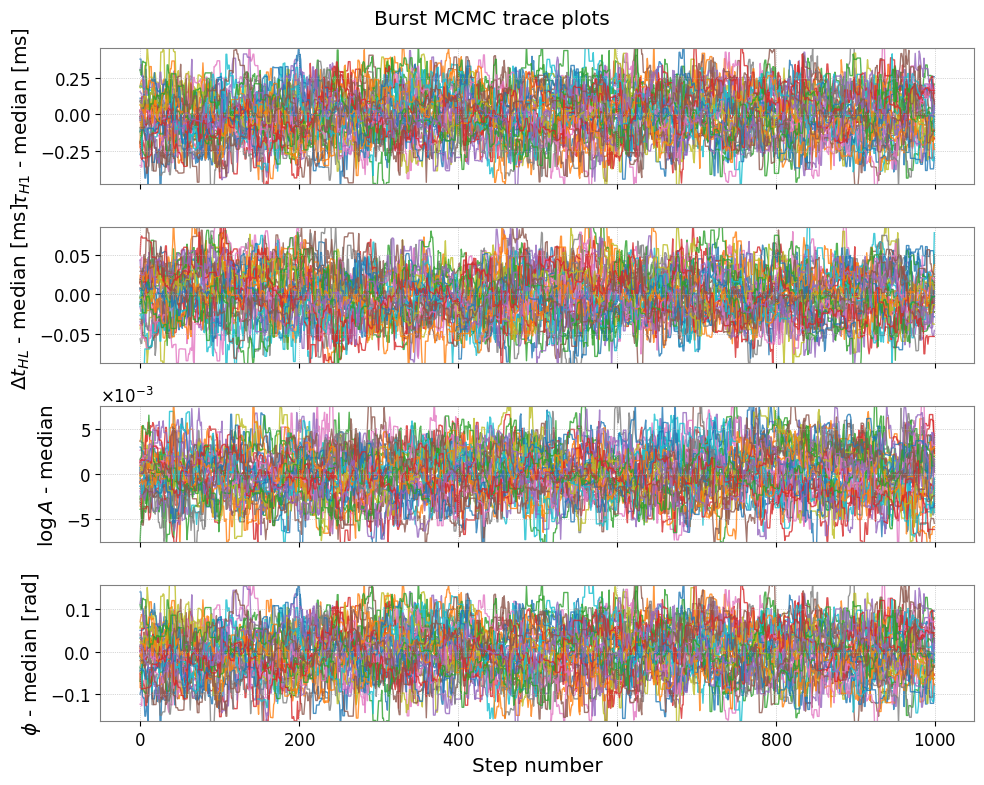

In [ ]:
# Labels and scaling factors for the burst trace plots
labels_4d_burst = [r"$\tau_{H1}$", r"$\Delta t_{HL}$", r"$\log A$", r"$\phi$"]
medians_burst = np.median(flat_samples_burst, axis=0)

# Convert timing parameters to ms
plot_scales_burst = np.array([1e3, 1e3, 1.0, 1.0])
units_burst = ["ms", "ms", "", "rad"]

# Plot the MCMC traces for a selected set of burst walkers
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for i in range(4):
    y_all = []

    for w in good_ids_burst:
        # Plot each walker relative to the posterior median for easier comparison
        y = plot_scales_burst[i] * (chain_burst[:1000, w, i] - medians_burst[i])
        y_all.append(y)
        axes[i].plot(y, lw=1.0, alpha=0.8)

    # Use the central 2nd-98th percentile range to set sensible y-axis limits
    y_all = np.concatenate(y_all)
    lo, hi = np.percentile(y_all[np.isfinite(y_all)], [2, 98])
    pad = 0.2 * (hi - lo + 1e-12)
    axes[i].set_ylim(lo - pad, hi + pad)

    # Label each subplot with the parameter name and units
    ylabel = labels_4d_burst[i]
    if units_burst[i]:
        ylabel += f" - median [{units_burst[i]}]"
    else:
        ylabel += " - median"

    axes[i].set_ylabel(ylabel)
    axes[i].grid(True, ls=":")

axes[-1].set_xlabel("Step number")
fig.suptitle("Burst MCMC trace plots")
plt.tight_layout()
plt.show()

The burst trace plots show that the walkers remain concentrated in a single dominant posterior region. The chains still fluctuate only within a very narrow range, so this posterior is also highly concentrated, but the overall behaviour is cleaner than in the CBC case. This makes the burst-reduced posterior easier to sample numerically, even though its physical interpretation remains limited by the model's simplicity.

In [ ]:
# Extract the posterior samples for each burst parameter from the MCMC chain
tau_samples_burst  = flat_samples_burst[:, 0]   # H1 time offset
dt_samples_burst   = flat_samples_burst[:, 1]   # H1-L1 delay
logA_samples_burst = flat_samples_burst[:, 2]   # overall log amplitude
phi_samples_burst  = flat_samples_burst[:, 3]   # common phase

# Compute the 16th, 50th, and 84th percentiles for each parameter
# These give the median and an approximate 1-sigma credible interval
tau_q_burst  = np.percentile(tau_samples_burst,  [16, 50, 84])
dt_q_burst   = np.percentile(dt_samples_burst,   [16, 50, 84])
logA_q_burst = np.percentile(logA_samples_burst, [16, 50, 84])
phi_q_burst  = np.percentile(phi_samples_burst,  [16, 50, 84])

# Print the posterior summary for the burst timing parameters
print("Burst tau_H1 [s]:")
print(f"  median = {tau_q_burst[1]:+.6f}")
print(f"  16-84% = [{tau_q_burst[0]:+.6f}, {tau_q_burst[2]:+.6f}]")

print("\nBurst dt_HL [s]:")
print(f"  median = {dt_q_burst[1]:+.6f}")
print(f"  16-84% = [{dt_q_burst[0]:+.6f}, {dt_q_burst[2]:+.6f}]")

# Print the posterior summary for the burst amplitude and phase parameters
print("\nBurst logA:")
print(f"  median = {logA_q_burst[1]:+.4f}")
print(f"  16-84% = [{logA_q_burst[0]:+.4f}, {logA_q_burst[2]:+.4f}]")

print("\nBurst phi [rad]:")
print(f"  median = {phi_q_burst[1]:+.4f}")
print(f"  16-84% = [{phi_q_burst[0]:+.4f}, {phi_q_burst[2]:+.4f}]")

Burst tau_H1 [s]:
  median = +0.009967
  16-84% = [+0.009807, +0.010128]

Burst dt_HL [s]:
  median = -0.009307
  16-84% = [-0.009337, -0.009277]

Burst logA:
  median = +5.9562
  16-84% = [+5.9536, +5.9588]

Burst phi [rad]:
  median = +11.2345
  16-84% = [+11.1792, +11.2909]


The burst posterior medians are sharply localised, especially in the timing parameters. The inferred H1–L1 delay is physically more plausible than the CBC-reduced fit, since it lies below the light-travel time between the Hanford and Livingston detectors ( which is approximately 0.01s). However, the fitted amplitude scale remains very large, so the burst amplitude should again be interpreted mainly as a nuisance parameter within the reduced model rather than as a direct physical observable.

I now visualise the reduced burst posterior with a corner plot, so that the compactness of the timing solution and any remaining parameter correlations can be seen more directly.

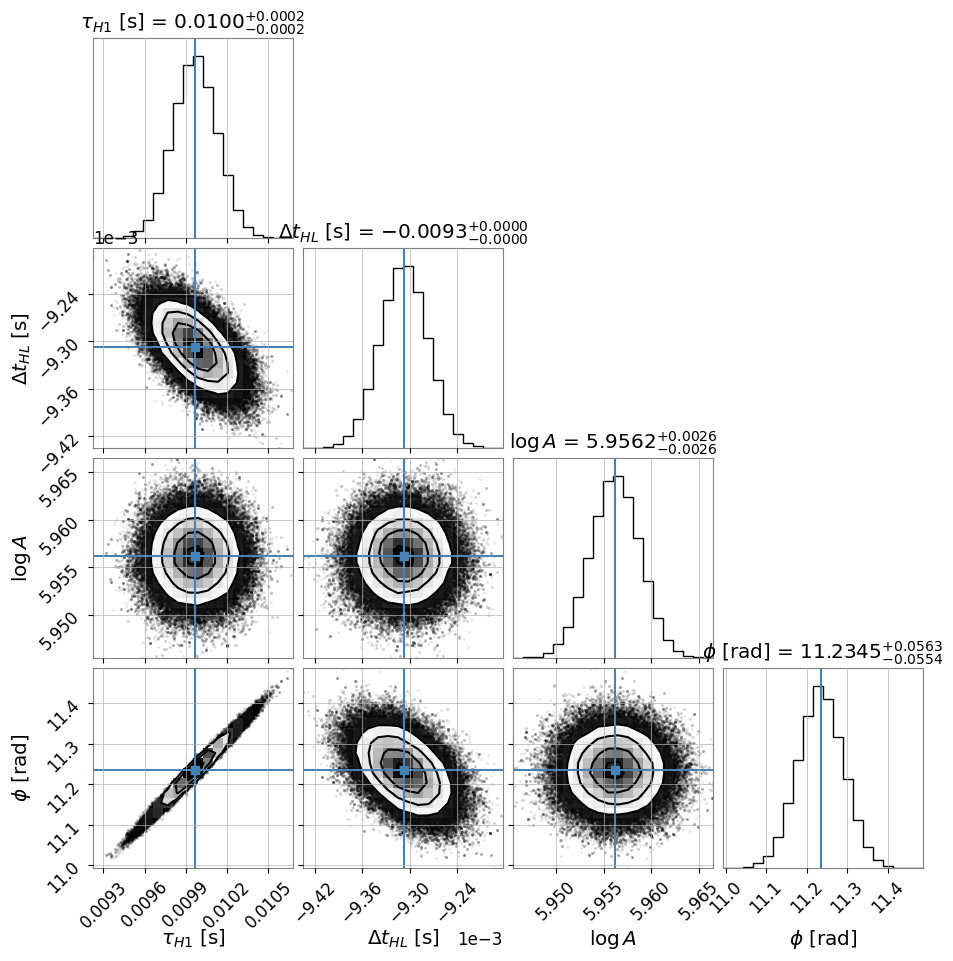

In [ ]:
# making the corner plot for visualisation
fig = corner.corner(
    flat_samples_burst,
    labels=[
        r"$\tau_{H1}$ [s]",
        r"$\Delta t_{HL}$ [s]",
        r"$\log A$",
        r"$\phi$ [rad]"
    ],
    truths=[
        np.median(tau_samples_burst),
        np.median(dt_samples_burst),
        np.median(logA_samples_burst),
        np.median(phi_samples_burst)
    ],
    show_titles=True,
    title_fmt=".4f"
)
plt.show()

The burst corner plot shows a single, compact, dominant posterior region, with no obvious evidence of multiple, separated modes. Compared to the CBC case, the burst posterior is numerically cleaner and easier to visualise.

### Part F

The two reduced coherent fits behave quite differently. The CBC fit produces a formally sharp posterior, but several parameters are pushed to prior boundaries, making the result difficult to interpret as a physically meaningful inference. The burst fit, on the other hand, is numerically cleaner and gives a more plausible inter-detector timing delay. However, its amplitude parameter remains very large and clearly acts as a nuisance compensation parameter. Taken together, these results suggest that neither reduced fit should be overinterpreted in isolation. The main value of this exercise is that it shows how sensitive short, high-mass events like GW231123 are to modelling assumptions, and how easily simplified parameterisations can become artificially restrictive (Abac et al. 2025).

In this project, I analysed GW231123 using open LIGO data and a simplified notebook-based workflow built around the methods covered in this course. Overall, my results are in broad agreement with the published picture of GW231123 as a short-duration, high-mass binary black hole event, but they also make it clear why this source is harder to interpret than a more standard BBH signal. In the whitened and filtered strain, the event appears as a compact transient with only a few visible cycles in band rather than a long chirp. That already matches the published description of GW231123 as a roughly 5-cycle signal in the $\sim 30$--$80\,\mathrm{Hz}$ range, with a network SNR of about 20.7 and source properties consistent with a very massive BBH merger with high component spins (Abac et al. 2025). The comparison with GW190521 is also natural here, since both events sit in the awkward regime where the signal is so short that interpretation becomes much less straightforward (Abbott et al. 2020b, 2020c).
The signal-model comparison in my notebook points in the same direction. The CBC template gives the cleaner matched-filter description of the event: its SNR response is more sharply localised and better timed than the burst response, even though the burst model still picks up a clear excess of short-duration power. That is not surprising. A burst model can reproduce the overall compact morphology of a signal like GW231123, but it cannot encode the detailed inspiral-merger-ringdown structure of a binary coalescence in the same way as a CBC waveform. This is also consistent with the published searches, where both compact-binary and burst pipelines recover the event, but with different inferred significances because they handle signal-background separation differently in this high-mass regime (Abac et al. 2025). :contentReference[oaicite:2]{index=2}

My simplified coincident background estimate also supports the detection interpretation, although in a much more basic way than the published analysis. In the notebook, the observed coincident statistic sits clearly above the accidental time-slide background, which is the same qualitative conclusion reached in the paper: GW231123 is a confident detection, and the coincidence between Hanford and Livingston is what makes that possible for such a short signal. At the same time, my IFAR bound should not be compared directly with the published numbers, since the real analysis uses dedicated low-latency and offline pipelines, improved background estimation, and more careful treatment of the data (Abac et al. 2025). :contentReference[oaicite:3]{index=3}

The main weakness in my own analysis shows up in the parameter-estimation section, and that actually lines up with one of the main points made in the literature. The GW231123 paper makes it very clear that this source lies in a difficult region for present waveform models, with noticeable disagreement between different BBH models and unusually large waveform systematics for a signal of this strength. My reduced coherent PE exercise shows the same issue in a stripped-down way. Once the waveform shape is fixed and only a few detector-response parameters are allowed to vary, the posterior can become artificially narrow or strongly prior-limited, and some nuisance parameters start soaking up model mismatch. So although my PE results are far less complete and far less reliable than the published Bayesian inference, they still point to the same basic lesson: for GW231123, modelling assumptions matter a lot (Abac et al. 2025). :contentReference[oaicite:4]{index=4}

As for the interpretation of the source itself, the simplest and most plausible one still seems to be a noneccentric BBH merger, but the literature also makes it clear that this is not the whole story. Because the signal is so short and has so few cycles in band, alternative interpretations are harder to dismiss than they would be for an ordinary lower-mass BBH event. The paper discusses the possibility of residual eccentricity or even a dynamical-capture origin, and that makes astrophysical sense because highly massive binaries formed in dense environments may not look like clean, long inspirals in the detector band. Similar ideas were also explored earlier in the case of GW190521 (Abac et al. 2025; Romero-Shaw et al. 2020a; Gamba et al. 2023).

Another important interpretation is that one or both of the black holes may be the product of earlier mergers. That is especially interesting here because the inferred component masses place the system partly within, or at least across, the expected pair-instability mass-gap range of roughly $60$--$130\,M_\odot$. The paper argues that this makes standard stellar-collapse channels less straightforward and points instead toward channels that can populate the gap, such as repeated BBH mergers, prior stellar mergers, or growth in a gaseous environment. Even that is not completely clean, though, because the inferred spins may be higher than what is usually expected in standard hierarchical-merger scenarios, and recoil kicks can make retention difficult in low-escape-speed environments (Abac et al. 2025; Farmer et al. 2019, 2020; Gerosa & Fishbach 2021).

More speculative alternatives also exist on high-mass, few-cycle GW events, including exotic compact-object mergers and cosmic-string-related scenarios. I do not test any of those possibilities here, and my results are not strong enough to distinguish between them. Still, the fact that GW231123 shares some of the same basic difficulties as GW190521 makes that wider discussion more relevant(Abbott et al. 2020b, 2020c; Romero-Shaw et al. 2020a; Calderón Bustillo et al. 2021b; Gayathri et al. 2022; Gamba et al. 2023; Aurrekoetxea et al. 2024).

Overall, this notebook supports the published interpretation of GW231123 as a confident and astrophysically important high-mass BBH merger, while also reproducing the main reason the event is so interesting in the first place: it lies in exactly the part of parameter space where waveform systematics, source-formation questions, and alternative interpretations all become more awkward than usual. So even though the analysis here is much simpler than the full LVK treatment, it still arrives at the same broad picture. GW231123 is most likely a very massive BBH merger, and one that may have produced an intermediate-mass black hole remnant (Abac et al. 2025).

## References

1. Abac, A. G., et al. (LIGO–Virgo–KAGRA Collaboration). 2025, *The Astrophysical Journal Letters*, **993**, L25. *GW231123: A Binary Black Hole Merger with Total Mass 190–265 M⊙*. DOI: 10.3847/2041-8213/ae0c9c.

2. Abbott, B. P., et al. (LIGO Scientific Collaboration and Virgo Collaboration). 2016, *Physical Review Letters*, **116**, 241102. *Properties of the Binary Black Hole Merger GW150914*. DOI: 10.1103/PhysRevLett.116.241102.

3. Abbott, B. P., et al. (LIGO Scientific Collaboration and Virgo Collaboration). 2017, *Physical Review Letters*, **119**, 161101. *GW170817: Observation of Gravitational Waves from a Binary Neutron Star Inspiral*. DOI: 10.1103/PhysRevLett.119.161101.

4. Abbott, R., et al. (LIGO Scientific Collaboration and Virgo Collaboration). 2020b, *Physical Review Letters*, **125**, 101102. *GW190521: A Binary Black Hole Merger with a Total Mass of 150 M⊙*. DOI: 10.1103/PhysRevLett.125.101102.

5. Abbott, R., et al. (LIGO Scientific Collaboration and Virgo Collaboration). 2020c, *The Astrophysical Journal Letters*, **900**(1), L13. *Properties and Astrophysical Implications of the 150 M⊙ Binary Black Hole Merger GW190521*. DOI: 10.3847/2041-8213/aba493.

6. Gerosa, D., & Fishbach, M. 2021, *Nature Astronomy*, **5**, 749–760. *Hierarchical mergers of stellar-mass black holes and their gravitational-wave signatures*. DOI: 10.1038/s41550-021-01398-w.

7. Romero-Shaw, I. M., Lasky, P. D., Thrane, E., & Calderón Bustillo, J. 2020a, *The Astrophysical Journal Letters*, **903**, L5. *GW190521: orbital eccentricity and signatures of dynamical formation in a binary black hole merger signal*. DOI: 10.3847/2041-8213/abbe26.

8. Farmer, R., Renzo, M., de Mink, S. E., Marchant, P., & Justham, S. 2019, *The Astrophysical Journal*, **887**, 53. *Mind the Gap: The Location of the Lower Edge of the Pair-instability Supernova Black Hole Mass Gap*. DOI: 10.3847/1538-4357/ab518b.

9. Farmer, R., Renzo, M., de Mink, S. E., Fishbach, M., & Justham, S. 2020, *The Astrophysical Journal Letters*, **902**(2), L36. *Constraints from Gravitational-wave Detections of Binary Black Hole Mergers on the 12C(α, γ)16O Rate*. DOI: 10.3847/2041-8213/abbadd.

10. Calderón Bustillo, J., Sanchis-Gual, N., Torres-Forné, A., et al. 2021b, *Physical Review Letters*, **126**, 081101. *GW190521 as a Merger of Proca Stars: A Potential New Vector Boson of 8.7 × 10⁻13 eV*. DOI: 10.1103/PhysRevLett.126.081101.

11. Gayathri, V., Healy, J., Lange, J., et al. 2022, *Nature Astronomy*, **6**. *Eccentricity estimate for black hole mergers with numerical relativity simulations*. DOI: 10.1038/s41550-021-01568-w.

12. Gamba, R., Breschi, M., Carullo, G., et al. 2023, *Nature Astronomy*, **7**, 11–17. *GW190521 as a dynamical capture of two nonspinning black holes*. DOI: 10.1038/s41550-022-01813-w.

13. Aurrekoetxea, J. C., Hoy, C., & Hannam, M. 2024, *Physical Review Letters*, **132**, 181401. *Revisiting the Cosmic String Origin of GW190521*. DOI: 10.1103/PhysRevLett.132.181401.